<div style="padding:25px; border-radius:10px;">

![](https://raw.githubusercontent.com/wateraccounting/WaPORMOOC/main/images/banner_notebooks_WaPOR4Global.png)


<div style="text-align:center; margin-top:15px;">
<h3 style="color:black; margin-bottom:5px;">
<i>Visualising WaPOR Analyses <br></i><b>From Country to Field &mdash; Iraq</b>
</h3>

<p style="color:black; margin-top:5px;">
<b>Estimated time:</b> 2 hours  &nbsp;
</p>
</div>

</div>

---

## 📚 Course Information

| Item | Description |
|------|-------------|
| **Course** | MOOC - WaPOR for Global Challenges |
| **Module** | 3 &mdash; Visualising WaPOR analyses |
| **Covers** | Lessons 1-2;(Exercises 1-2): Time-series. |
| **Scale** | Country (18 governorates)
| **Data** | AgERA5 monthly (1980&ndash;2025);

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Load and inspect** monthly and annual climate data (rainfall and reference ET) for multiple locations and verify temporal coverage and structure.
2. **Select the right chart type** for each question — overlaid lines for a collective overview, small multiples for individual comparison, bar charts for seasonal rhythm, and heatmaps for population-level patterns.
3. **Read a seasonal cycle critically** — identifying months of water surplus (P > ET₀) and deficit (ET₀ > P), and explaining why the calendar year framing can misrepresent Iraq's wet season.
4. **Choose colormaps deliberately** — sequential for raw magnitudes, diverging for anomalies and Z-scores — and explain why the wrong choice produces misleading charts.
5. **Interpret long-term trends** — distinguishing statistical significance from practical significance, and stating correctly what a non-significant result does and does not mean.
6. **Analyse inter-annual variability** using standardised anomaly heatmaps (Z-scores) to identify synchronous drought years across governorates.
7. **Classify aridity** using the UNEP Aridity Index (P/ET₀) and explain what the index captures and what it leaves out for water planning decisions.

---

> 💡 **How to read this notebook.** Each chart is followed by a **🔍 Visualization Lens** box (what the chart shows, what works, what to watch for, what to improve, plus a quick 🔔 quiz) and often a **💬 Forum** box with a hands-on task.

---

## 📖 Table of Contents

1. Environment Setup
2. Input Data Preparation
3. Temporal Patterns — The Big Picture
4. The Clock of Seasons — Monthly Climatology
   - 4a. All governorates — line graph
   - 4b. All governorates — bar charts sorted by rainfall
   - 4c. Heatmap — 18 × 12 monthly climatology
   - 4d. Selected governorates — seasonal comparison
5. Reference ET Time Series — All Governorates
6. Seasonal Cycle — Rainfall & Reference ET Side by Side
   - 6a. Paired climatology heatmap
   - 6b. Long-term trends — rainfall & ET
   - 6c. Rainfall anomaly — space × time heatmap
   - 6d. Aridity Index (P / ET₀)
7. Downloading the Plots

---

## ⚙️ 1. Environment Setup
<p style="margin-top:1px;">
	Some Python packages are required that may not be included in a basic Python installation. Run the cells below to set up your environment.
	</p>

In [ ]:
# =============================================================================
# Install the required packages
# =============================================================================

%%capture
!pip install numpy pandas matplotlib seaborn scipy
!pip install geopandas          # Optional — for map visualisation


In [ ]:
# =============================================================================
# Import packages
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import os, zipfile
import warnings
from datetime import datetime

# Optional: spatial mapping
try:
    import geopandas as gpd
    GPD_AVAILABLE = True
    print("✅ geopandas loaded")
except ImportError:
    GPD_AVAILABLE = False
    print("ℹ️ geopandas not installed — map sections will be skipped")

# --- Configuration ---
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [14, 7]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("\n✅ Setup complete — Pandas " + pd.__version__ + ", NumPy " + np.__version__)
print("📅 Analysis date: " + datetime.now().strftime('%Y-%m-%d'))


## ⚙️ 2. Input data preparation
<p style="margin-top:1px;">
Create folders for where to upload the input data and where to store the results.


In [ ]:
# =============================================================================
# DATA FOLDER SETUP
# =============================================================================

data_folder   = 'data'
output_folder = 'output_data'
os.makedirs(data_folder,   exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

### Upload the data files
Place the following data files in a new folder called `data/` (source of data: AgERA5 for the period 1980-2025):

| File | Description |
|------|-------------|
| `irq_admin1_AgERA5-PCP-M_mm` | Monthly rainfall (mm/month) for 18 governorates of Iraq|
| `irq_admin1_AgERA5-RET-M_mm.csv` | Monthly reference evapotranspiration (mm/month) for 18 governorates of Iraq|
| `output_data_notebook_2.1.zip` | Annual rainfall (mm/year) for 18 governorates of Iraq from Notebook 2.1 | 

**Expected CSV format:** First column = date (`DD/MM/YYYY`), remaining columns = governorate names.

*Instructions on how to download the required data is provided in this [Notebook](notebook link).

In [ ]:
# Upload data from Notebook_1
from google.colab import files
uploaded = files.upload()

# Save each file to the destination folder
for filename, content in uploaded.items():
    dest_path = f'/content/data/{filename}'
    with open(dest_path, 'wb') as f:
        f.write(content)
    print(f" Saved: {dest_path}")

In [ ]:

# Upload the `output_data_notebook_2.1.zip` exported from Notebook_2.1 before running this cell.
#
#   Colab: Files panel (left sidebar) → drag `output_data_notebook_2.1.zip` onto the panel → Run.


# --- Extract zip if present ---
_zip_candidates = ['data.zip', 'output_data_notebook_2.1.zip', , 'output_data.zip']
_extracted = False

for _zname in _zip_candidates:
    if os.path.exists(_zname):
        print(f"📦 Found {_zname} — extracting ...")
        with zipfile.ZipFile(_zname) as _zf:
            _zf.extractall('_tmp_extract')
        # Flatten nested folders → move all files into data/
        for _root, _dirs, _files in os.walk('_tmp_extract'):
            for _f in _files:
                if not _f.startswith('.'):
                    _src = os.path.join(_root, _f)
                    _dst = os.path.join(data_folder, _f)
                    if not os.path.exists(_dst):
                        os.rename(_src, _dst)
        # Cleanup temp folder
        import shutil
        shutil.rmtree('_tmp_extract', ignore_errors=True)
        print(f"   ✅ Extraction complete.")
        _extracted = True
        break

if not _extracted:
    print("ℹ️  No zip found — assuming files are already in data/.")

# --- Verify ---
_found = sorted(os.listdir(data_folder)) if os.path.exists(data_folder) else []
if _found:
    print(f"\n✅ {len(_found)} file(s) found in data/:")
    for _f in _found:
        print(f"   · {_f}")
else:
    print("\n⚠️  data/ folder is empty.")
    print("   Upload data.zip via the Files panel (left sidebar) and re-run.")

📦 Found data.zip — extracting ...
   ✅ Extraction complete.

✅ 12 file(s) found in data/:
   · ai_mean.csv
   · data.zip
   · irq_admin1_AgERA5-PCP-M_mm.csv
   · irq_admin1_AgERA5-RET-M_mm.csv
   · rain_annual.csv
   · rain_month.csv
   · rain_stats.csv
   · rain_trend.csv
   · ret_annual.csv
   · ret_month.csv
   · ret_stats.csv
   · ret_trend.csv


### Define data format
First the format of the data needs to be defined. In the following script, the
CSV file is read from a file path, different dates formats are recognised and the first column is idenfitied as date and it is sorted.

In [ ]:
# =============================================================================
# DEFINING DATA FORMAT & PATH RESOLUTION
# =============================================================================

def _resolve_csv(folder, filename):
    """
    Return the full path to a data file, raising a clear error if missing.
    This avoids a confusing error message deep inside pandas.
    """
    path = os.path.join(folder, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required data file not found: {path}\n"
            f"  • Upload it to the data/ folder and re-run the cell above."
        )
    return path


def load_governorate_data(filepath, name='dataset'):
    """
    Load monthly governorate-level data from CSV.
    Expects: first column = date, remaining columns = governorates.

    Handles both comma- and semicolon-delimited files automatically.
    """
    # --- Auto-detect delimiter ---
    with open(filepath, 'r', encoding='utf-8-sig') as fh:
        first_line = fh.readline()
    delimiter = ';' if first_line.count(';') > first_line.count(',') else ','

    try:
        df = pd.read_csv(filepath, delimiter=delimiter)
    except Exception as e:
        print(f"❌ Could not read {name} ({filepath}): {e}")
        return None

    date_col = df.columns[0]

    # Parse dates (try explicit formats first, then dayfirst=True fallback).
    # These CSVs use DD/MM/YYYY, so dayfirst is the correct fallback.
    parsed = False
    for fmt in ['%d/%m/%Y', '%m/%d/%Y', '%Y-%m-%d', '%Y/%m/%d']:
        try:
            df[date_col] = pd.to_datetime(df[date_col], format=fmt)
            parsed = True
            break
        except (ValueError, TypeError):
            continue
    if not parsed:
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')

    df.set_index(date_col, inplace=True)
    df.index.name = 'date'
    df = df.sort_index()

    # Ensure every data column is numeric (non-numeric → NaN, not an error)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print(f"📄 {name}: {df.shape[0]} months × {df.shape[1]} governorates")
    print(f"   Period: {df.index.min().strftime('%b %Y')} — {df.index.max().strftime('%b %Y')}")
    print(f"   Governorates: {', '.join(df.columns[:5])}{'...' if df.shape[1] > 5 else ''}")
    return df


### Read data files
The `load_governorate_data` function is run using the following script for each data file. For this exercise you read monthly rainfall and reference ET data from AgERA5 for the period 1980-2025.

Check if for each data set you have data for the entire period.

In [ ]:
# =============================================================================
# READ DATA FILES
# =============================================================================

# --- Load monthly raw data (used to recompute climatology in this notebook) ---
df_rain     = load_governorate_data(_resolve_csv(data_folder, 'irq_admin1_AgERA5-PCP-M_mm.csv'), name='Rainfall')
rain_annual = load_governorate_data(_resolve_csv(data_folder, 'rain_annual.csv'),      name='Annual Rainfall')

# --- Load pre-computed analysis outputs ---
rain_stats = pd.read_csv(_resolve_csv(data_folder, 'rain_stats.csv'), index_col=0)
rain_trend = pd.read_csv(_resolve_csv(data_folder, 'rain_trend.csv'), index_col='Governorate')
ret_stats  = pd.read_csv(_resolve_csv(data_folder, 'ret_stats.csv'),  index_col=0)
ai_mean    = pd.read_csv(_resolve_csv(data_folder, 'ai_mean.csv'),    index_col=0)

# --- Governorate list (used by every downstream plotting cell) ---
governorates    = df_rain.columns.tolist()
n_gov           = len(governorates)
representatives = ['Duhok', 'Erbil', 'Baghdad']   # north / semi-arid / central
print("\n\U0001f4cd " + str(n_gov) + " governorates: " + str(governorates))
print("   Representative selection: " + str(representatives))
# --- Also load Reference ET raw data (needed for ET small-multiples & seasonal charts) ---
df_ret      = load_governorate_data(_resolve_csv(data_folder, 'irq_admin1_AgERA5-RET-M_mm.csv'), name='Reference ET')
ret_annual = load_governorate_data(_resolve_csv(data_folder, 'ret_annual.csv'),       name='Annual Reference ET')



---

## 📊 3. Temporal Patterns - The Big Picture
We start with plotting the raw time series. Run the cell below to visualise the monthly rainfall for all governorates.

***Exercise:*** update the code to visualise the Reference ET data as well.

In [ ]:
# =============================================================================
# RAINFALL TIME SERIES - ALL GOVERNORATES IN ONE GRAPH
# =============================================================================
# Monthly data — all 18 lines overlaid (sanity check: correct seasonal shape?)
df_rain.plot(legend=False, title='Monthly Rainfall — all governorates overlaid')
plt.show()

# Annual totals — all 18 lines overlaid
rain_annual.plot(legend=False, title='Annual Rainfall — all governorates overlaid')
plt.show()



## 3a. Create individual graphs
The combined graph above is difficult to read with 18 governorates overlapping.
The cell below draws one panel per governorate — a layout known as **small multiples**.

***Exercise: understand the code line by line***

Run the cell once to see the default output. Then work through it line by line:
comment out a line (add `#` at the start so Python skips it), run again, and observe
what changes. Each line has a `▶` hint telling you exactly what to expect.
When you are done, remove the `#` and move on to the next one.

Once you feel confident, the clean version of the code is below, copy it into a new cell and adapt it to plot the **Reference ET** series instead.



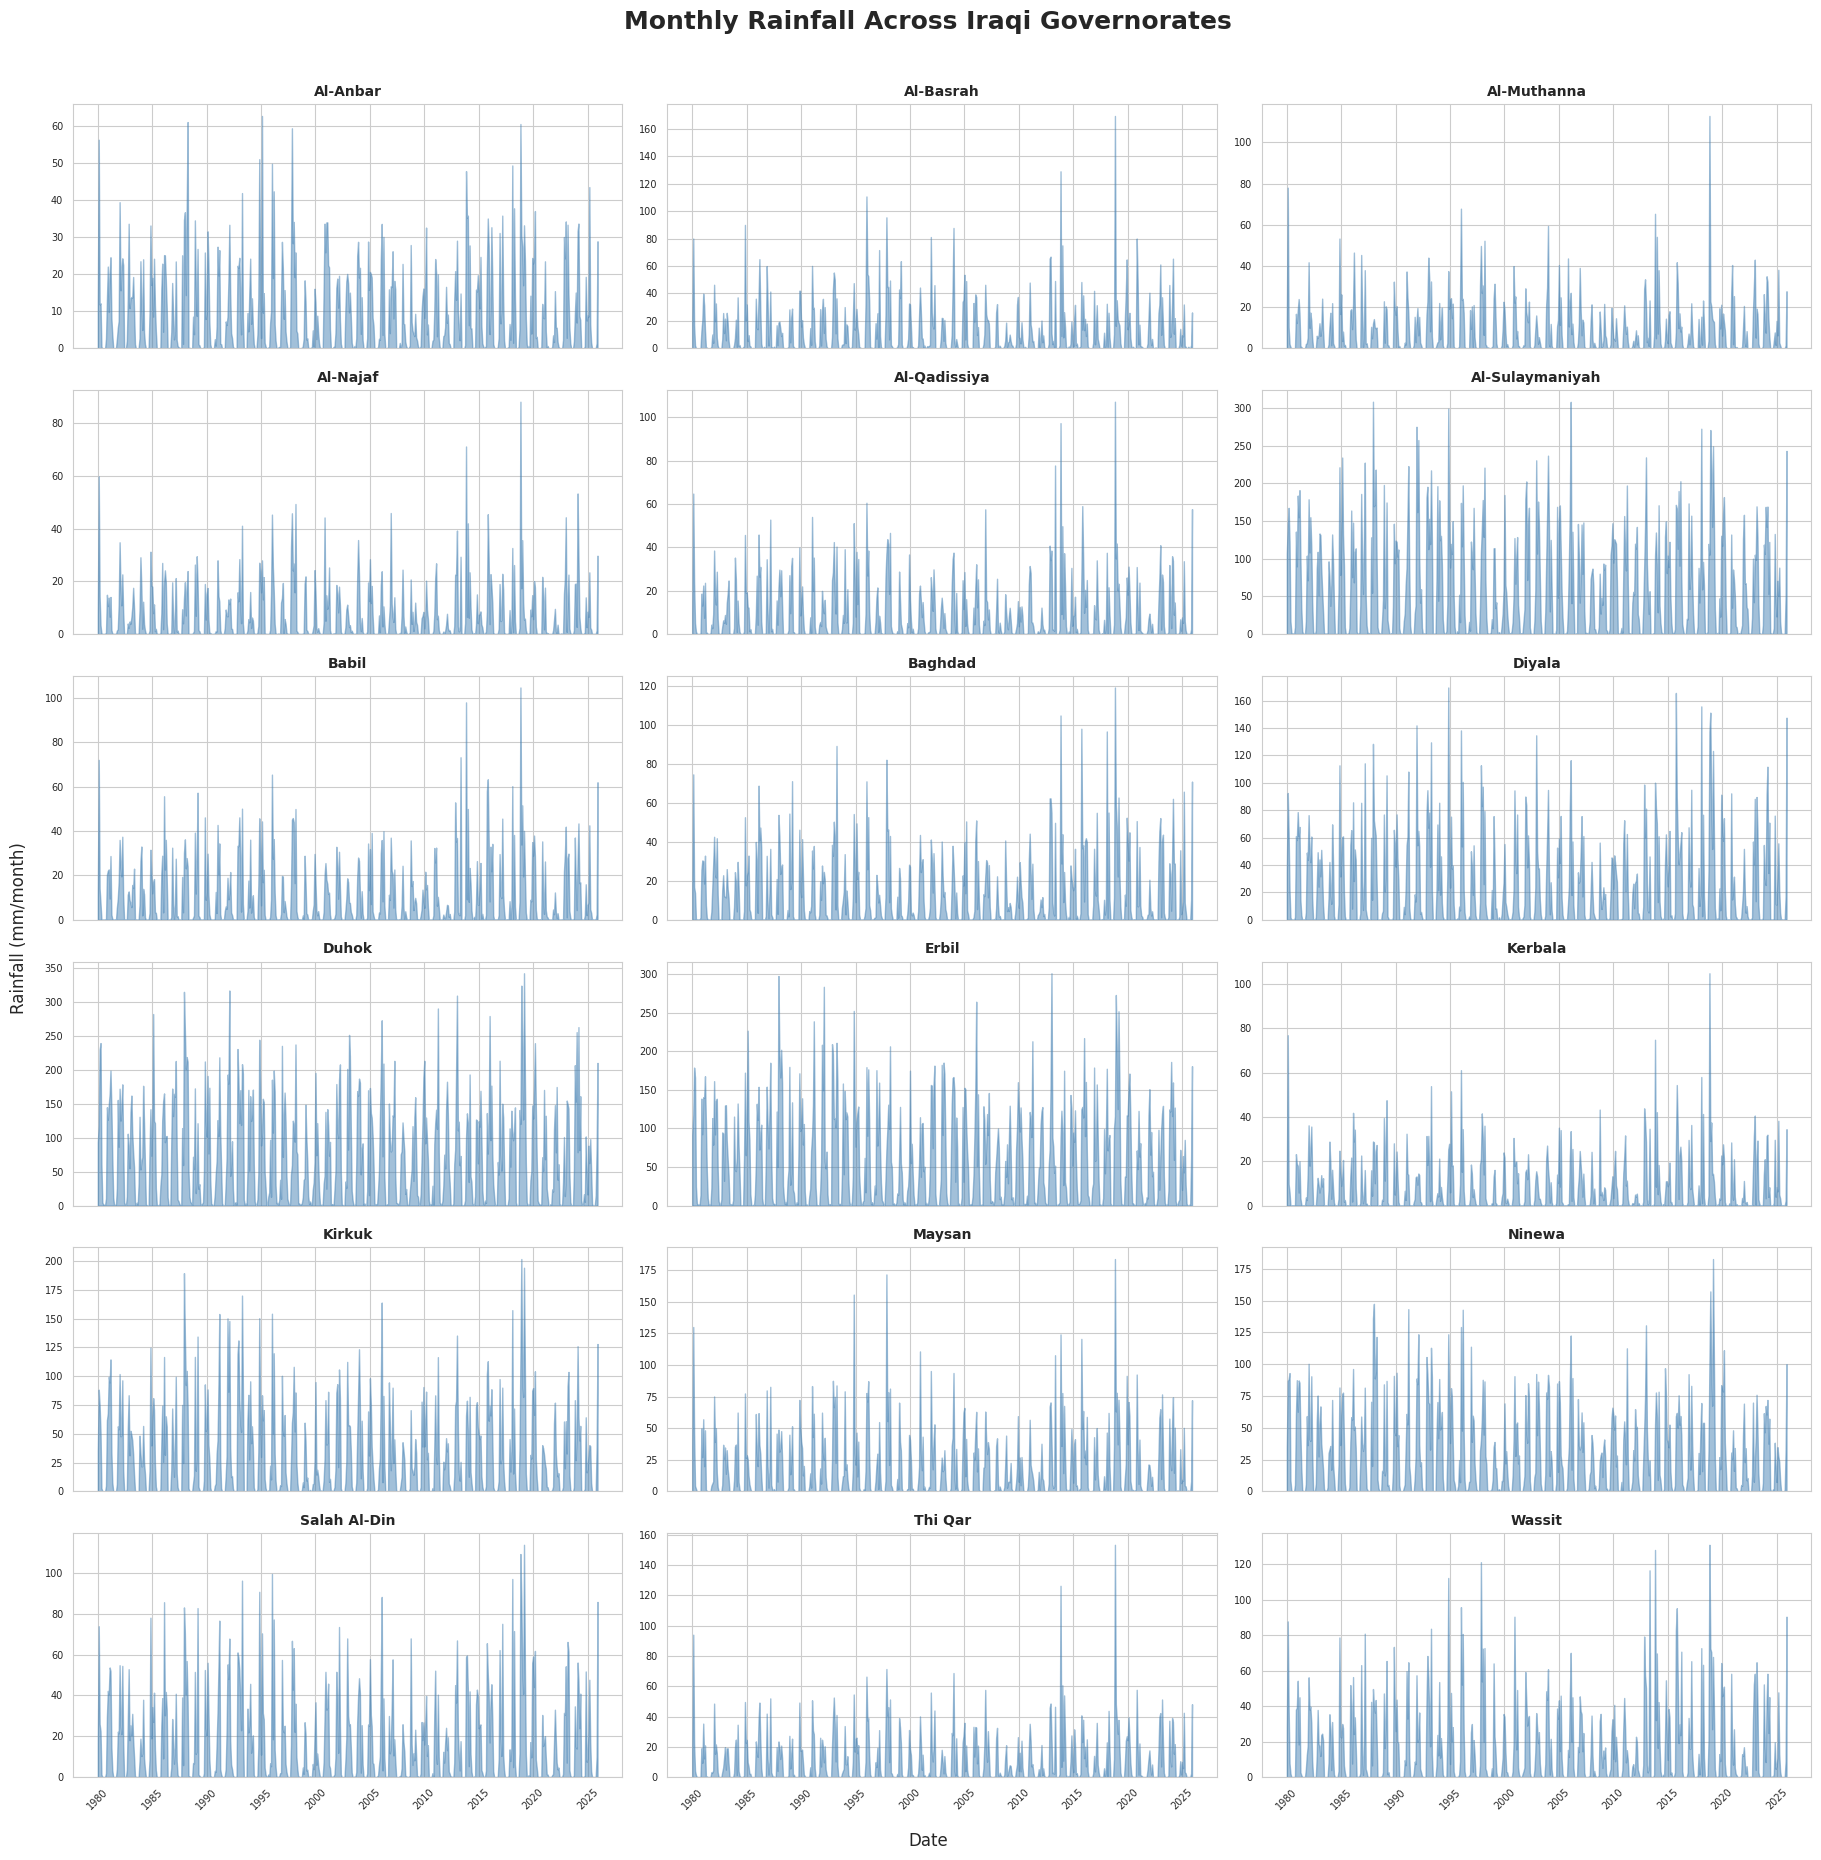

In [ ]:
# =============================================================================
# RAINFALL TIME SERIES - ALL GOVERNORATES (Small Multiples)
# =============================================================================

n_cols = 3
n_rows = (n_gov + n_cols - 1) // n_cols

# ▶ RUN the cell as-is first. Then try: change n_cols to 2 or 4 and run again.
# Notice how n_rows adjusts automatically and the whole grid reflows.

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
# ▶ Comment out sharex=True (leave just figsize), run again.
#fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
# Each panel now zooms its x-axis independently — harder to compare across governorates.
# Uncomment it back when done.

fig.suptitle('Monthly Rainfall Across Iraqi Governorates',
             fontsize=18, fontweight='bold', y=1.01)
# ▶ Comment out the two lines above and run again — no title at all.
# Then restore them and change y=1.01 to y=0.98 — the title overlaps the panels.

axes_flat = axes.flatten()

for idx, gov in enumerate(governorates):
    ax = axes_flat[idx]
    ax.fill_between(df_rain.index, 0, df_rain[gov], color='steelblue', alpha=0.5)
    # ▶ Change alpha=0.5 to alpha=1 and run — no transparency.
    # Then try alpha=0.1 — almost invisible. Put 0.5 back.
    # ▶ Change color='steelblue' to color='salmon' and run to see the difference.
    ax.set_title(gov, fontsize=10, fontweight='bold')
    ax.set_ylim(bottom=0)
    # ▶ Comment out set_ylim and run — panels with low rainfall will auto-scale upward
    # and look falsely large compared to wetter governorates.
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    # ▶ Change rotation=45 to rotation=0 and run — dates collide and overlap.
    ax.tick_params(axis='y', labelsize=7)

for idx in range(n_gov, len(axes_flat)):
    axes_flat[idx].set_visible(False)
# ▶ Comment out the two lines above and run — you'll see empty grey boxes
# where governorates don't fill the last row. Uncomment to hide them again.

fig.text(0.5, -0.01, 'Date', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Rainfall (mm/month)', va='center',
         rotation='vertical', fontsize=12)
# ▶ Comment out both fig.text lines and run — no axis labels at all.
# Notice that without them it's unclear what the numbers mean.

plt.tight_layout()
# ▶ Comment out tight_layout and run — panels overlap each other and the title.
plt.show()

> 🎨 **Note: want to explore more colours?**
>
> Matplotlib and Plotly each have full colour catalogues you can browse:
> [Matplotlib colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html) · [Plotly built-in colorscales](https://plotly.com/python/builtin-colorscales/)
> Any colour name or hex code you find there can be dropped straight into `color=` in the cells below.

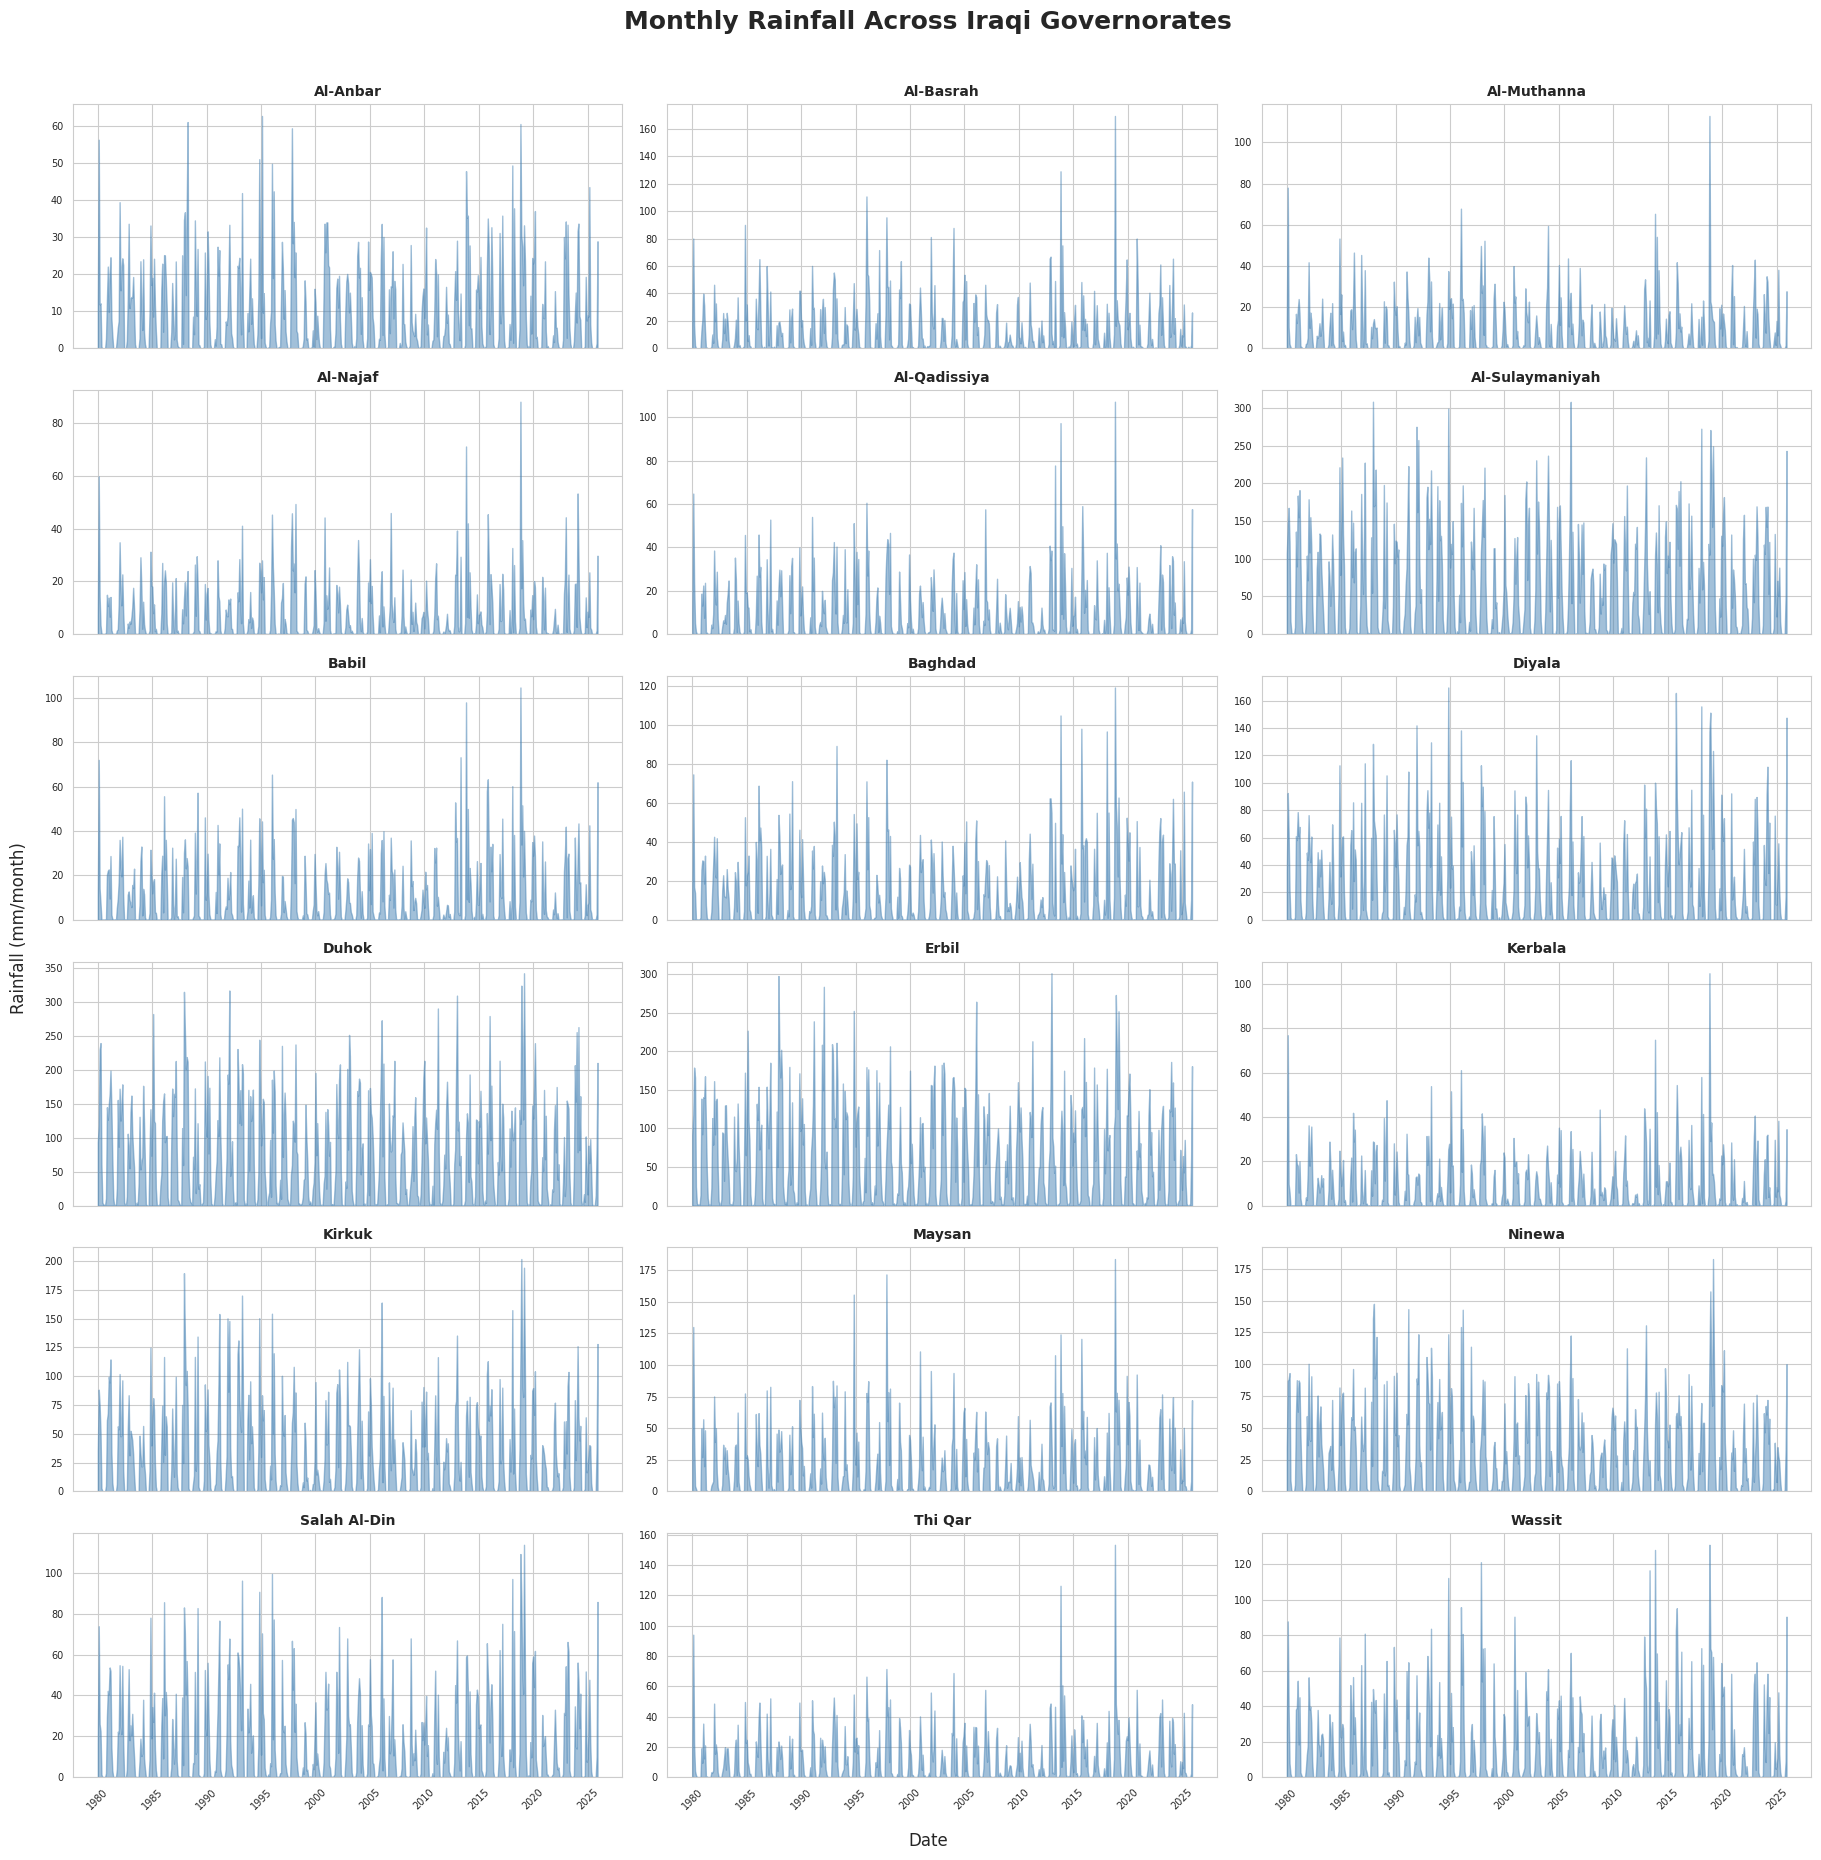

In [ ]:
# =============================================================================
# RAINFALL TIME SERIES - ALL GOVERNORATES (Small Multiples)
# =============================================================================

n_cols = 3
n_rows = (n_gov + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
fig.suptitle('Monthly Rainfall Across Iraqi Governorates',
             fontsize=18, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for idx, gov in enumerate(governorates):
    ax = axes_flat[idx]
    ax.fill_between(df_rain.index, 0, df_rain[gov], color='steelblue', alpha=0.5)
    ax.set_title(gov, fontsize=10, fontweight='bold')
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Remove empty subplots
for idx in range(n_gov, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.text(0.5, -0.01, 'Date', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Rainfall (mm/month)', va='center',
         rotation='vertical', fontsize=12)
plt.tight_layout()
plt.show()

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
Monthly rainfall for each of the 18 governorates over 46 years, with a 12-month moving average to smooth interannual noise.
>
>**What works well:**
`sharex=True` means the same year lines up vertically across all panels — making it easy to spot synchronous drought events (e.g., 2008, 2021) without scanning axes. The `fill_between` shading communicates volume rather than just shape.
>
>**What to watch out for:**
Panels are ordered alphabetically, not by climate regime. The north–south gradient in rainfall is real and large, but invisible in the panel layout - a reader scanning the grid has no visual cue about which panels represent similar climates.
>
>Note also that the 12-month rolling mean is truncated at the end of the record. The last several months show a declining MA simply because future data does not yet exist, not a real drying signal. Do not interpret the tail of the moving average as a trend.
>
>**What could be improved:**
Sort panels by mean annual rainfall (driest to wettest). This simple reordering makes the rainfall gradient visible as a spatial gradient across the grid - no data change needed.
>
>---
>
>🔔 **QUIZ**
>
>**The 18 panels are in alphabetical order.**
>**Which reordering would make the north–south climate gradient immediately >visible in the panel layout?**
>
>A) Reverse alphabetical order
>
>B) Sort by mean annual rainfall — driest to wettest (or wettest to driest)
>
>C) Sort by governorate latitude, north to south
>
>D) Keep alphabetical but use a different colormap

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ B**

*Sorting by mean rainfall groups governorates with similar regimes together. Dry southern panels (small sparse bars) cluster at one end; wet northern panels (tall dense bars) at the other. The climate gradient becomes a visual gradient — readable at a glance.*

*Try that and post your results in the course forum.*
</details>

In [ ]:
# =============================================================================
# REFERENCE ET TIME SERIES - ALL GOVERNORATES (Small Multiples)
# =============================================================================

# For the color, 'orangered' or 'brown' work better than steelblue here —
#ax.fill_between(df_ret.index, 0, df_ret[gov], color='orangered', alpha=0.5)


## 📶 3b. Plotting
<p style="margin-top:1px;">
Lets plot the rainfall stations in one horizontal bar chart in ascending order. Play around with the settings to get the graph the way you like or need it for your report or presentation.  

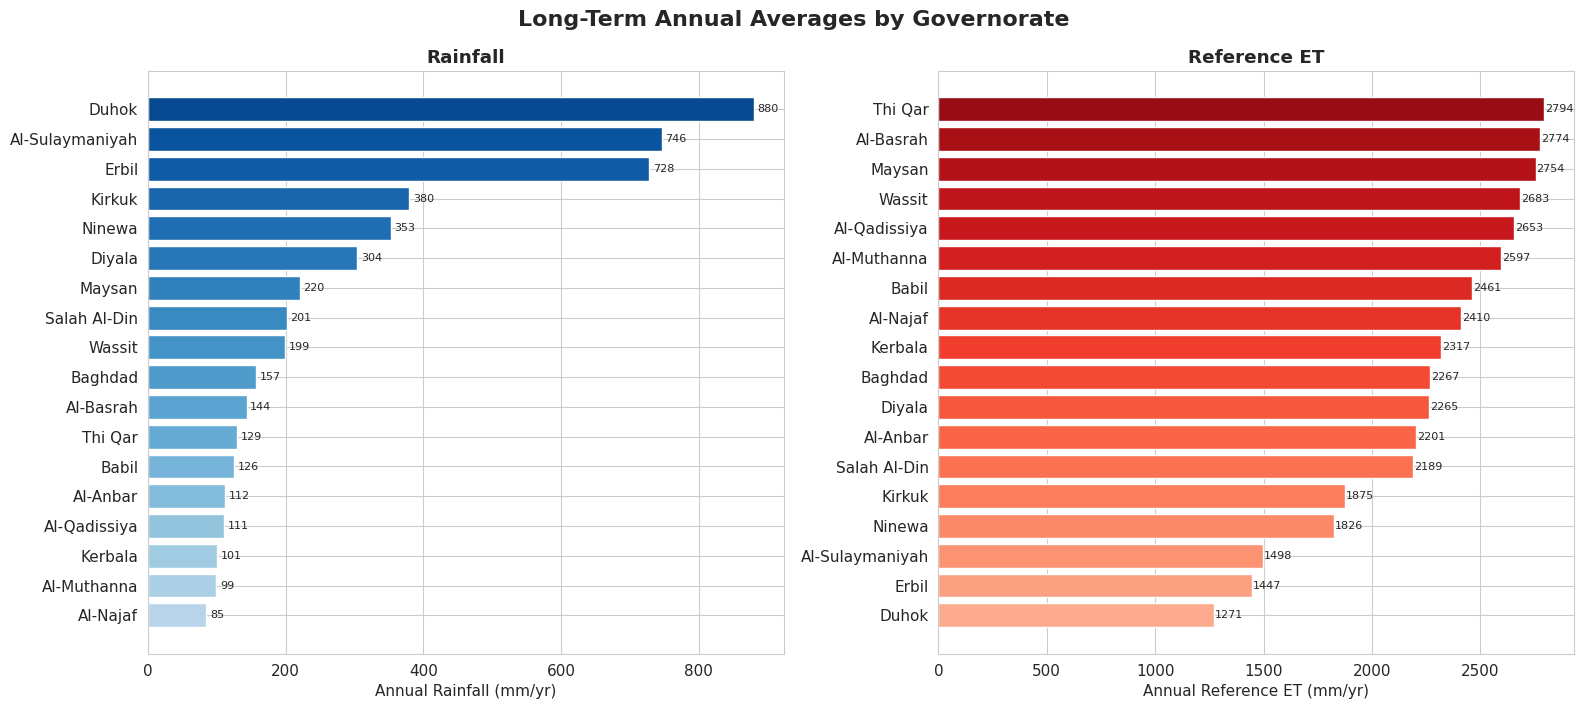

💡 Key Insight:
   Rainfall ranges from ~85 to ~880 mm/yr across governorates (Al-Najaf to Duhok),
   while Reference ET ranges ~1270–2790 mm/yr — higher everywhere than rainfall.
   ALL of Iraq has a structural water deficit - ET demand far exceeds rainfall supply.


In [ ]:
# =============================================================================
# ANNUAL TOTALS — RAINFALL & REFERENCE ET SIDE BY SIDE
# =============================================================================
# Replicates the Lesson 01 side-by-side layout so both variables are visible
# in a single figure, ordered by rainfall (wettest → driest).

sorted_govs_rain = rain_stats.sort_values('mean', ascending=True).index.tolist()
sorted_govs_et   = ret_stats.sort_values('mean',  ascending=True).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, n_gov * 0.4)))
fig.suptitle('Long-Term Annual Averages by Governorate',
             fontsize=16, fontweight='bold')

# --- Rainfall (left panel) ---
ax1 = axes[0]
colors_rain = plt.cm.Blues(np.linspace(0.3, 0.9, n_gov))
bars1 = ax1.barh(sorted_govs_rain,
                  rain_stats.loc[sorted_govs_rain, 'mean'],
                  color=colors_rain, edgecolor='white')
ax1.set_xlabel('Annual Rainfall (mm/yr)')
ax1.set_title('Rainfall', fontweight='bold')
for bar, val in zip(bars1, rain_stats.loc[sorted_govs_rain, 'mean']):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f'{val:.0f}', va='center', fontsize=8)

# --- Reference ET (right panel) ---
ax2 = axes[1]
colors_et = plt.cm.Reds(np.linspace(0.3, 0.9, n_gov))
bars2 = ax2.barh(sorted_govs_et,
                  ret_stats.loc[sorted_govs_et, 'mean'],
                  color=colors_et, edgecolor='white')
ax2.set_xlabel('Annual Reference ET (mm/yr)')
ax2.set_title('Reference ET', fontweight='bold')
for bar, val in zip(bars2, ret_stats.loc[sorted_govs_et, 'mean']):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f'{val:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("💡 Key Insight:")
print("   Rainfall ranges from ~85 to ~880 mm/yr across governorates (Al-Najaf to Duhok),")
print("   while Reference ET ranges ~1270–2790 mm/yr — higher everywhere than rainfall.")
print("   ALL of Iraq has a structural water deficit - ET demand far exceeds rainfall supply.")

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
Long-term mean annual rainfall and mean reference ET for all 18 governorates, ranked to reveal the magnitude contrast between north and south.
>
>**What works well:**
Sorted horizontal bars make the rainfall gradient immediately readable. Value labels at bar tips give exact numbers without requiring the reader to judge axis position.
>
>**What to watch out for:**
The two charts are sorted independently — rainfall by rainfall rank, ET by ET rank. A reader's eye naturally expects the same governorate to appear at the same row in both panels. It does not. Visually comparing Baghdad's rainfall with Baghdad's ET requires finding Baghdad in two different positions — a subtle but real misreading risk.
>
>**What could be improved:**
Sort both panels by the same variable (e.g. rainfall rank), so any governorate appears at the same vertical position in both charts. Or replace both bar charts with a scatter plot (P on x, ET₀ on y, one dot per governorate), which removes the ordering problem entirely. Try those and post your results in the course forum.
>
>---
>
>🔔 **QUIZ**
>
>**The rainfall chart is sorted by rainfall mean. The ET chart is sorted by ET mean.**
>**What is the potential misreading risk for a reader comparing the two panels?**
>
>A) The blue and red color ramps make magnitudes hard to compare
>
>B) The same governorate appears at different row positions in the two panels — a reader scanning left-to-right may compare two different governorates by mistake
>
>C) Bar charts cannot show two variables side by side
>
>D) The value labels overlap on the longer bars

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ B**

*Duhok ranks first in rainfall (880 mm/yr) but last in ET demand (1271 mm/yr — coolest, highest elevation). With independent sorting, Duhok sits at the top of the rainfall chart but near the bottom of the ET chart. A reader who assumes the same row means the same governorate will compare Duhok's rainfall with a different governorate's ET. Sorting both by rainfall rank, or using a scatter plot, prevents this.*

</details>

---

## ⏱️ 4. The Clock of Seasons — Monthly Climatology

Monthly climatology — the average value for each month across all years — reveals the **seasonal heartbeat** of Iraq’s climate. This is the background pattern against which all variability and change are measured.

### Calculate the mean monthly values
First lets calculate the mean monthly values and assign the names of the month to the first column (index).

In [ ]:
# =============================================================================
# MONTHLY CLIMATOLOGY FOR RAINFALL
# =============================================================================

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute monthly climatology
rain_clim = df_rain.groupby(df_rain.index.month).mean()
rain_clim.index = month_names

print(rain_clim)

     Al-Anbar  Al-Basrah  Al-Muthanna  Al-Najaf  Al-Qadissiya  \
Jan     18.60      29.36        20.17     16.23         20.91   
Feb     17.89      18.62        13.91     13.54         16.27   
Mar     19.33      23.30        15.37     11.91         17.33   
Apr     11.75      10.17         9.16      8.57         10.91   
May      4.25       3.40         2.61      2.40          4.60   
Jun      0.18       0.13         0.04      0.04          0.04   
Jul      0.01       0.08         0.01      0.00          0.01   
Aug      0.05       0.19         0.02      0.03          0.04   
Sep      0.25       0.20         0.09      0.11          0.18   
Oct      6.52       4.69         3.17      3.05          3.35   
Nov     15.86      28.08        18.79     14.98         18.67   
Dec     16.94      25.25        15.91     14.02         18.83   

     Al-Sulaymaniyah  Babil  Baghdad  Diyala  Duhok  Erbil  Kerbala  Kirkuk  \
Jan           124.69  21.80    25.74   51.96 135.81 117.18    17.59   64.86

In [ ]:
# =============================================================================
# MONTHLY CLIMATOLOGY FOR REFERENCE ET
# =============================================================================

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute monthly climatology
ret_clim = df_ret.groupby(df_ret.index.month).mean()
ret_clim.index = month_names

print(ret_clim)

     Al-Anbar  Al-Basrah  Al-Muthanna  Al-Najaf  Al-Qadissiya  \
Jan     55.24      75.14        76.76     69.64         71.01   
Feb     76.92     102.38       103.45     94.81         97.90   
Mar    135.75     168.86       171.37    162.34        167.09   
Apr    193.42     232.73       228.80    218.22        227.81   
May    260.22     314.55       299.03    284.53        303.90   
Jun    308.13     394.16       350.23    321.56        369.85   
Jul    339.71     413.68       373.88    346.01        395.86   
Aug    303.00     376.18       340.68    312.27        363.12   
Sep    225.86     292.19       262.25    241.86        275.89   
Oct    159.83     205.78       197.33    184.17        195.48   
Nov     86.86     118.36       113.46    103.12        110.44   
Dec     56.45      79.44        79.86     71.52         74.98   

     Al-Sulaymaniyah  Babil  Baghdad  Diyala  Duhok  Erbil  Kerbala  Kirkuk  \
Jan            33.76  64.39    53.86   50.22  26.42  30.73    59.46   40.18

## 4a. Visualize the monthly values
Lets visualize this data using the line graph style. The graphs show the values according to the calendar (Jan-Dec). To update the graphs following the hydrological year (Sep-Aug), remove the comments under *"reorder months to start from September"* and rerun the cell.

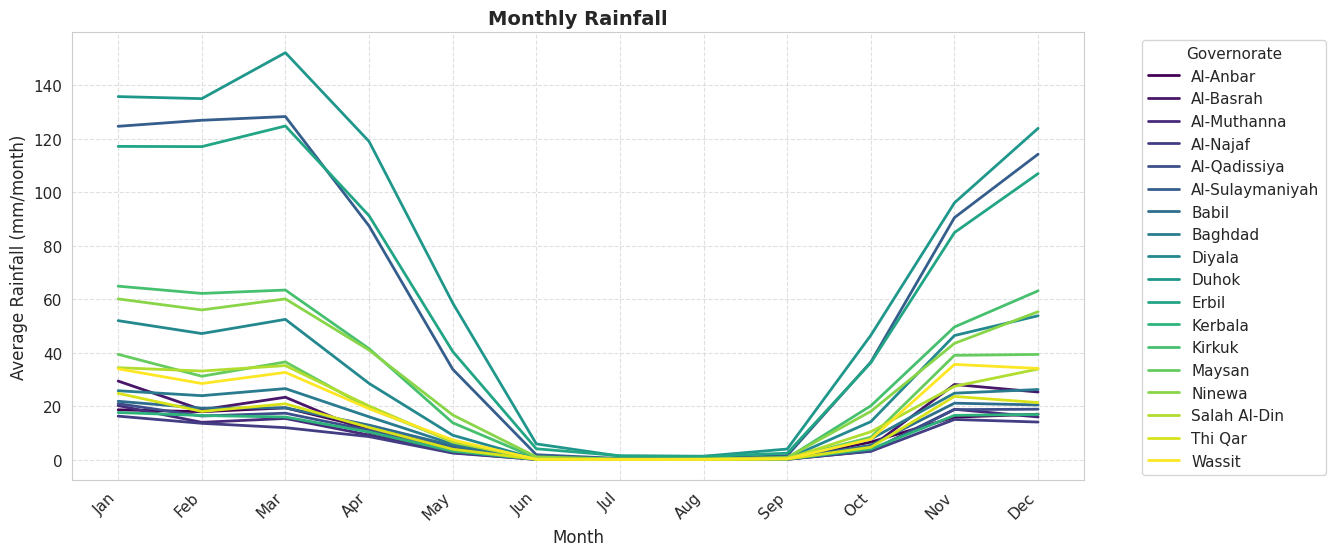

In [ ]:
# =============================================================================
# VISUALISING MONTHLY RAINFALL
# =============================================================================

# Reorder months to start from September
#month_order_sept_aug = ['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
#rain_clim = rain_clim.reindex(month_order_sept_aug)
#month_names = month_order_sept_aug

fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Plot each governorate's monthly climatology as a line
rain_clim.plot(ax=ax, cmap='viridis', linewidth=2)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Rainfall (mm/month)', fontsize=12)
ax.set_title('Monthly Rainfall', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(month_names)))
ax.set_xticklabels(month_names, rotation=45, ha='right')
ax.legend(title='Governorate', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0.03, 0.85, 0.98]) # Adjust layout to make space for the legend
plt.show()

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
The average seasonal rainfall cycle for all 18 governorates on a single axis, using a viridis color ramp.
>
>**What works well:**
The collective shape is instantly visible: all 18 governorates drop to near-zero in Jun–Sep and peak Nov–Apr. The spread of lines in winter months encodes the north–south magnitude difference at a glance.
>
>**What to watch out for:**
With 18 overlapping lines and 18 legend entries, individual governorate identification is nearly impossible. The chart is useful as a collective overview, but any conclusion about a specific governorate requires switching to a different chart.
>
>There is also a framing choice hidden in the x-axis: the calendar year (Jan–Dec) splits Iraq's wet season — Oct–Dec appear on the right edge and Jan–Apr on the left, creating a visual gap in what is physically one continuous wet period.
>
>**What could be improved:**
For individual-level questions, use the small-multiple bar charts or the heatmap instead. For the seasonal framing, uncomment the hydrological year reordering (Sep–Aug) already in the code — this centres the wet season and gives a more natural reading for water planning.
>
>---
>
>🔔 **QUIZ**
>
>**The x-axis runs Jan–Dec (calendar year). The code includes a commented-out option to reorder to Sep–Aug (hydrological year).**
>**For an irrigation planner in Iraq, which axis framing is more meaningful and why?**
>
>A) Jan–Dec, because it matches the standard calendar everyone is familiar with
>
>B) Sep–Aug, because it keeps Iraq's wet season contiguous in the middle of the chart
>
>C) It makes no difference — the data is the same either way
>
>D) Jun–May, centred on the dry season instead

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ B — Sep–Aug (hydrological year), because it keeps Iraq's wet season contiguous.**

*On a Jan–Dec axis, the wet season is split: Oct–Dec sits at the right edge and Jan–Apr at the left, creating an artificial gap in what is a single continuous wet period. The hydrological year (Sep–Aug) centres the wet season in the middle of the chart and places the dry summer months at both edges — matching how hydrologists and farmers think about the annual water cycle.*

</details>

## 4b. Create individual graphs

Rainfall is often presented in bar charts. To create individual bar charts per governorate, run the cell below.


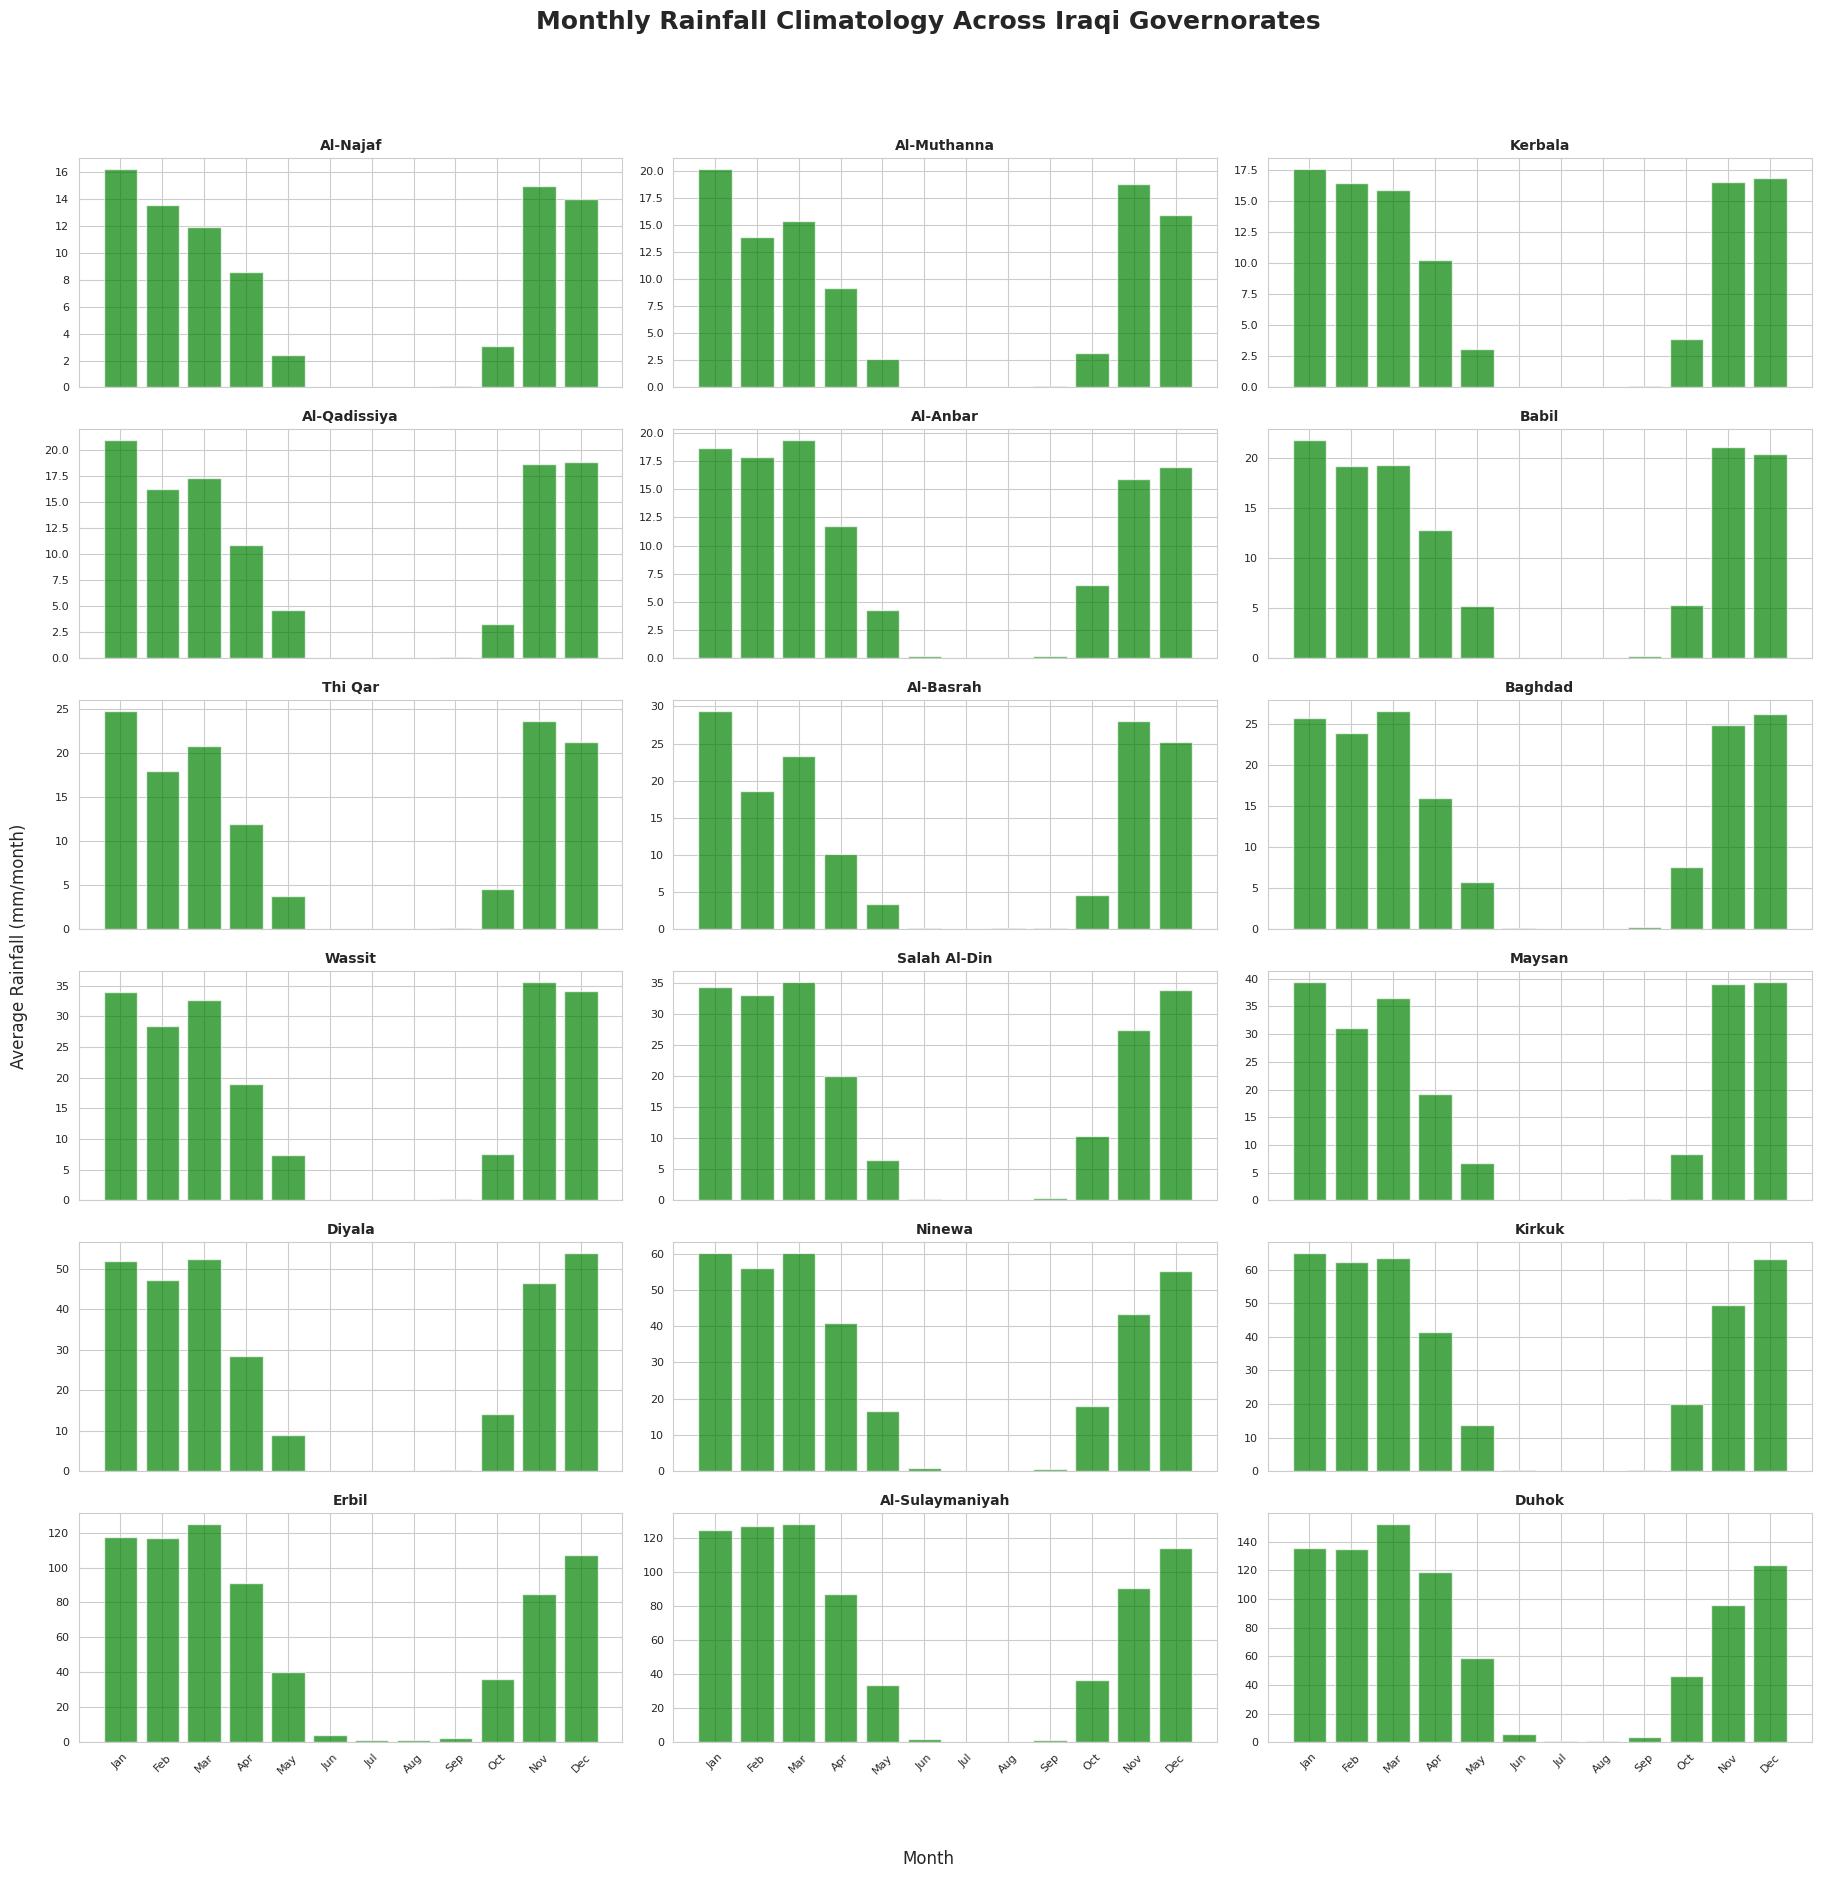

In [ ]:
# =============================================================================
# MONTHLY RAINFALL - VERTICAL BAR GRAPHS (Small Multiples)
# =============================================================================
sorted_govs_rain = rain_stats.sort_values('mean', ascending=True).index.tolist()

n_cols = 3 # Number of columns for subplots
n_rows = (n_gov + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True, sharey=False)
fig.suptitle('Monthly Rainfall Climatology Across Iraqi Governorates',
             fontsize=18, fontweight='bold', y=1.02)

axes_flat = axes.flatten()

for idx, gov in enumerate(sorted_govs_rain):
    ax = axes_flat[idx]
    ax.bar(rain_clim.index, rain_clim[gov], color='green', alpha=0.7)
    ax.set_title(gov, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylim(bottom=0) # Ensure y-axis starts from 0

# Remove empty subplots if any
for idx in range(len(sorted_govs_rain), len(axes_flat)):
    axes_flat[idx].set_visible(False);

fig.text(0.5, -0.01, 'Month', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Average Rainfall (mm/month)', va='center',
         rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
The seasonal rainfall distribution for each governorate as a bar chart, panels sorted by mean annual rainfall.
>
>**What works well:**
Sorting panels by mean rainfall (driest first) is a good choice: as you move through the panels, bars grow taller and the wet-season peak extends later into spring. The climate gradient becomes visible as a progression through the grid. `sharey=False` (independent y-axes) is correct here — the goal is to show each governorate's seasonal rhythm, not compare magnitudes.
>
>**What to watch out for:**
The bars are green here, but the time series panels above used blue for rainfall. Using different colors for the same variable across different charts in the same notebook adds cognitive load — the reader has to re-learn the color mapping for each new chart.
>
>**What could be improved:**
Use the same color for rainfall consistently throughout the notebook (e.g. `#2166ac`, matching Lesson 02's `var_config`). One color = one variable is the simplest and most powerful cognitive aid in a multi-chart report.
>
>---
>
>🔔 **QUIZ**
>
>**The small-multiple panels are sorted by mean annual rainfall. A colleague suggests switching to alphabetical order instead.**
>**What specific visual insight would be lost?**
>
>A) The x-axis month labels would become harder to read
>
>B) The visual progression from sparse dry-south bars to tall wet-north bars would disappear — the north–south climate gradient would only be readable by scanning labels, not by seeing it
>
>C) The `sharey=False` setting would no longer work correctly
>
>D) Nothing — panel ordering is purely aesthetic

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ B**

*Sorted by rainfall, the reader sees an unbroken visual progression: bars grow taller as panels advance. The spatial gradient from the dry south to the wet north becomes a visual gradient in the chart. Alphabetically sorted, this progression disappears — the climate story becomes invisible in alphabetical noise.*

</details>

## 4c. Creating heatmap

There is a lot of information presented in the 18 graphs, a heatmap will help visualise the results.

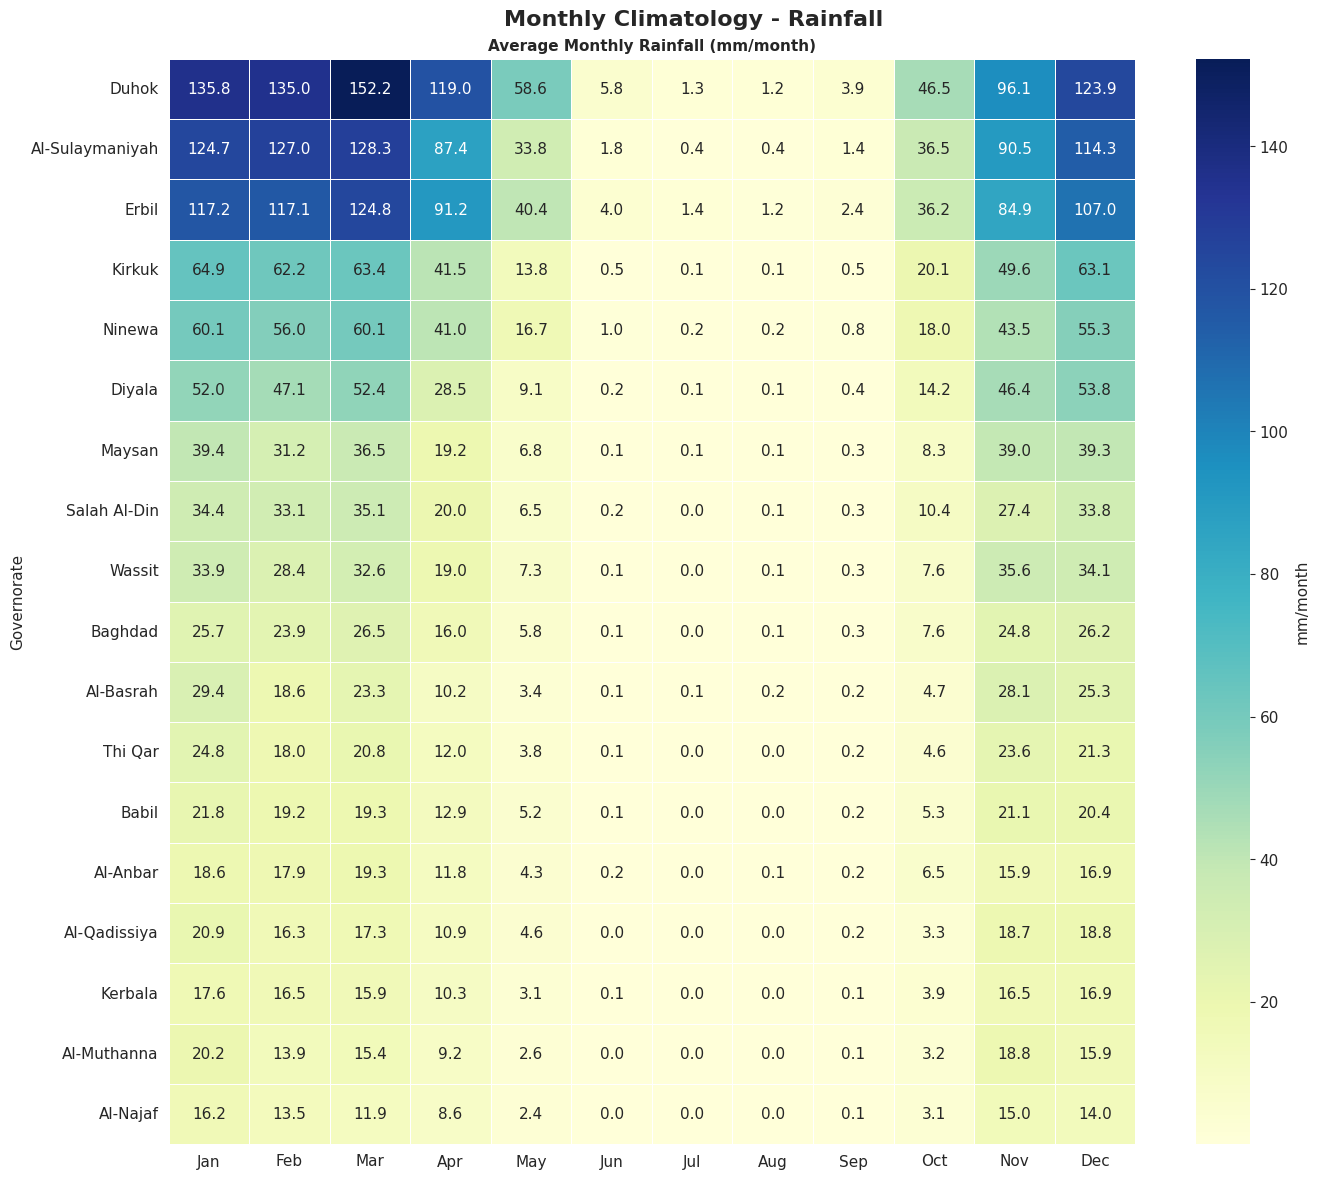

In [ ]:
# =============================================================================
# MONTHLY RAINFALL HEATMAP
# =============================================================================

# Sort governorates by annual rainfall (wettest first)
sorted_govs = rain_stats.sort_values('mean', ascending=False).index.tolist()

fig, axes = plt.subplots(1, 1, figsize=(max(14, n_gov * 0.4), 12))
fig.suptitle('Monthly Climatology - Rainfall',
             fontsize=16, fontweight='bold')

# --- Rainfall Heatmap ---
sns.heatmap(rain_clim[sorted_govs].T, ax=axes, cmap='YlGnBu',
            annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'mm/month'})
axes.set_title('Average Monthly Rainfall (mm/month)', fontsize=11, fontweight='bold')
axes.set_ylabel('Governorate')
axes.set_xlabel('')

plt.tight_layout()
plt.show()

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
Average monthly rainfall for all 18 governorates simultaneously, as an 18 × 12 matrix sorted by annual mean.
>
>**What works well:**
The heatmap encodes 216 values in one chart. Scanning down the March column reveals the north–south magnitude gradient directly: top rows (north) are deep blue in March; bottom rows (south) are already pale yellow. A secondary timing difference is also visible in the shoulder months (April–May): northern panels retain meaningful rainfall into April (~ 61 mm average) while southern panels are essentially dry (~ 12 mm). This contrast requires mental scanning across 18 individual bar charts to see, but is instantaneous here.
>
>**What to watch out for:**
The colormap `YlGnBu` is sequential and correct for raw rainfall magnitudes. If this same heatmap were used for anomalies (deviations from average) instead of raw values, a sequential colormap would be the wrong choice — because below-average and above-average years are both meaningful and need to be distinguishable from a neutral center. This is one of the most common colormap errors in climate science.
>
>**What could be improved:**
Keep `YlGnBu` here — it is correct. But note the rule for later: when the data has a meaningful midpoint (anomalies, trends, correlations), switch to a diverging colormap (e.g. `RdYlBu`) centered at that midpoint.
>
>---
>
>🔔 **QUIZ**
>
>**The heatmap uses `YlGnBu` — a sequential colormap. This is correct for raw rainfall values.**
>**For which of the following datasets would `YlGnBu` be the WRONG choice?**
>
>A) Monthly reference ET values (mm/month)
>
>B) Annual NPP values (gC/m²/year)
>
>C) Standardised rainfall anomalies (Z-scores, where positive = wet, negative = dry)
>
>D) Mean annual AETI (mm/year)

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ C — standardised anomalies (Z-scores)**

*Z-scores diverge from a meaningful midpoint: Z = 0 means exactly average, positive means wetter than average, negative means drier. Both directions carry equal importance. A sequential colormap (`YlGnBu`) would map low Z as light and high Z as dark, hiding the direction of the deviation. A diverging colormap (e.g. `RdYlBu`) centered at zero correctly encodes both wet and dry anomalies. Options A, B, and D are all non-negative magnitudes with no meaningful midpoint — sequential is correct.*

</details>

## 4c. Compare patterns for selected governorates
To compare the seasonal rainfall patterns of three selected governorates. Create a simple line graph using the script below.

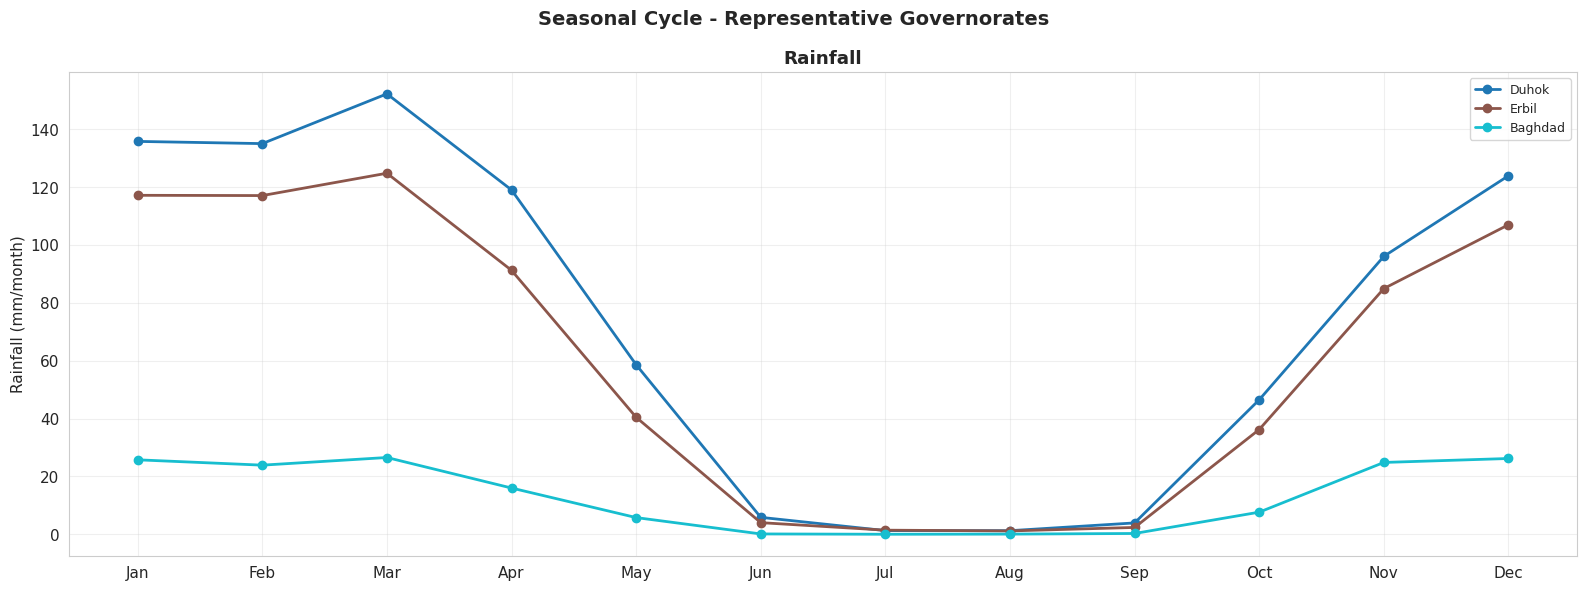

In [ ]:
# =============================================================================
# SEASONAL RAINFALL PATTERNS - SELECTED GOVERNORATES
# =============================================================================

fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.suptitle('Seasonal Cycle - Representative Governorates',
             fontsize=14, fontweight='bold')

selection = ['Duhok', 'Erbil', 'Baghdad']
colors = plt.cm.tab10(np.linspace(0, 1, len(selection)))

# --- Rainfall ---
ax1 = axes
for gov, color in zip(selection, colors):
    ax1.plot(range(1, 13), rain_clim[gov].values, 'o-', color=color,
             linewidth=2, markersize=6, label=gov)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_ylabel('Rainfall (mm/month)')
ax1.set_title('Rainfall', fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
The seasonal rainfall pattern for a small selection of governorates, allowing direct comparison of magnitude and timing.
>
>**What works well:**
Reducing to 3 lines makes individual governorate identity, magnitude, and timing all readable at once. The same color is used for each governorate in both the rainfall and ET panels — so the reader can track one location across both variables without re-reading the legend.
>
>**What to watch out for:**
The selection of governorates is not stated or justified in the notebook. Any chart built from a subset carries selection bias: the reader cannot know whether the shown governorates are typical or exceptional without seeing the full population.
>
>**What could be improved:**
State the selection rationale explicitly — e.g. *"Duhok (north, humid), Erbil (north, dry sub-humid), Baghdad (centre, arid) — representing the three main climate zones."* This turns an implicit choice into a transparent one. For any population-level claim, refer the reader to the heatmap instead.
>
>---
>
>🔔 **DISCUSS**
>
>**This chart shows 3 of 18 governorates.**
>**Before drawing a general conclusion from it, what question should you always ask about a chart built from a selected subset?**
>
>Post your answer in the course forum before reading below.

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ "Why these three — and were they chosen before or after looking at the data?"**

*A selection made after seeing the data risks confirming a pattern that happens to be visible in the chosen cases but not across all 18. The sound practice is to state the selection criterion explicitly (e.g. one governorate per climate zone) and to use the heatmap when the claim is about all governorates.*

</details>

---

## 5. Reference ET Time Series — All Governorates

The exercise below mirrors the rainfall small-multiples panel. Reference ET (ET₀) is the evaporative demand of the atmosphere, estimated here from the AgERA5 climate reanalysis using the FAO-56 Penman-Monteith equation.
Compare the panel shapes carefully with the rainfall panels above.

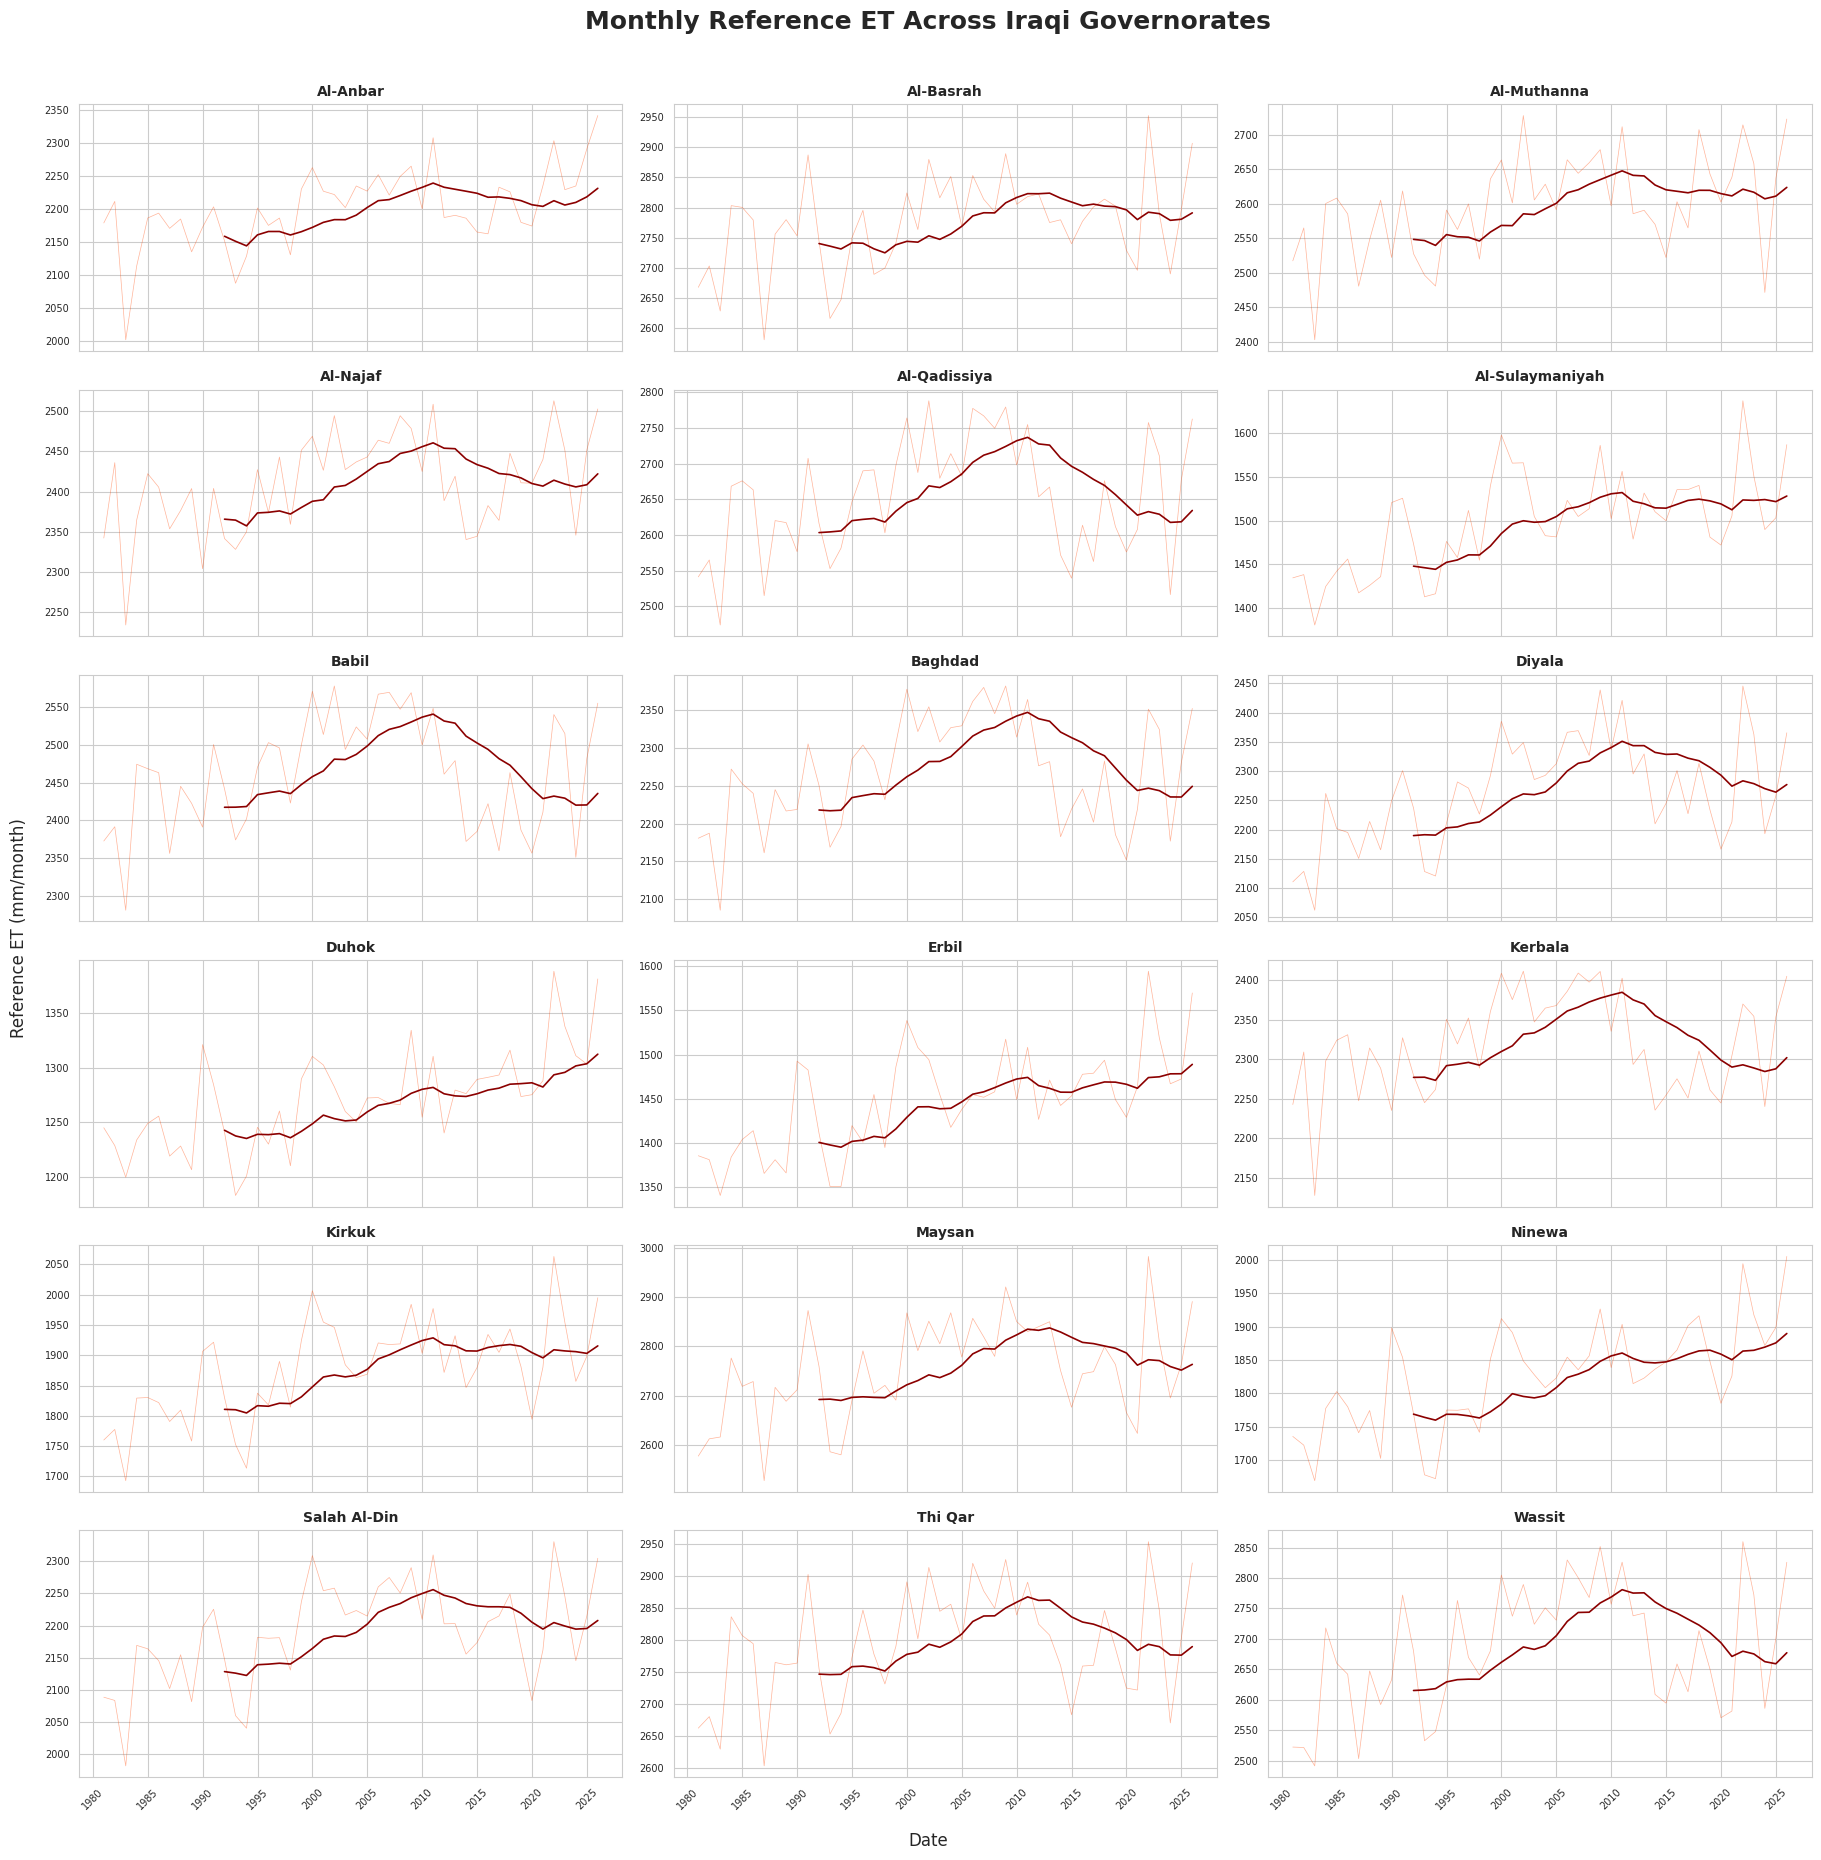

💡 ET is strongly seasonal — peaks Jun-3Aug, near-minimum in Dec-Jan.
➡️ Crucially, the north-south spread is narrow: unlike rainfall (85–880 mm/yr, Al-Najaf to Duhok),
➡️ Annual ET ranges only ~1270-2794 mm/yr. The sun imposes similar demand, everywhere; geography determines water supply, not demand.


In [ ]:
# =============================================================================
# REFERENCE ET TIME SERIES — ALL GOVERNORATES (Small Multiples)
# =============================================================================

n_cols = 3
n_rows = (n_gov + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
fig.suptitle('Monthly Reference ET Across Iraqi Governorates',
             fontsize=18, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for idx, gov in enumerate(governorates):
    ax = axes_flat[idx]
    ax.plot(ret_annual[gov], color='orangered', alpha=0.4, linewidth=0.5)
    ax.plot(ret_annual[gov].rolling(12).mean(), color='darkred', linewidth=1.2,
            label='12-month MA')
    ax.set_title(gov, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

for idx in range(n_gov, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.text(0.5, -0.01, 'Date', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Reference ET (mm/month)', va='center',
         rotation='vertical', fontsize=12)
plt.tight_layout()
plt.show()

print("💡 ET is strongly seasonal — peaks Jun-3Aug, near-minimum in Dec-Jan.")
print("➡️ Crucially, the north-south spread is narrow: unlike rainfall (85–880 mm/yr, Al-Najaf to Duhok),")
print("➡️ Annual ET ranges only ~1270-2794 mm/yr. The sun imposes similar demand, everywhere; geography determines water supply, not demand.")



>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
Monthly Reference ET for all 18 governorates, 1980–2025, with a 12-month moving average.
>
>**What works well:**
Using a warm palette (orangered/darkred) for ET and a cool palette (steelblue/darkblue) for rainfall across the notebook creates an immediate visual grammar: cool = supply, warm = demand. The moving average reveals a slow upward trend in several governorates that would be invisible in raw monthly noise.
>
> 🎨 **Note — want to explore more colours?**
> Matplotlib and Plotly each have full colour catalogues you can browse:
> [Matplotlib colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html) · [Plotly built-in colorscales](https://plotly.com/python/builtin-colorscales/)
> Any colour name or hex code you find there can be dropped straight into `color=` in the cells.
>
>**What to watch out for:**
The y-axes are independent (`sharey` is not set), which is correct — the seasonal *shape* is the lesson here, not inter-governorate magnitude comparison. However, a reader scanning panels may unconsciously compare peak heights across panels as if axes were shared. A note in the title or caption should flag this.
>
>**What could be improved:**
Consider adding a subtle shading to the Jun–Aug dry-season months on each panel to make the demand-season explicit without text. A simple `ax.axvspan` call per panel is sufficient.
>
>---
>
>🔔 **DISCUSS**
>
>**ET panels look almost identical across governorates. Rainfall panels look very different.**
>**What does this tell you about the *origin* of Iraq's water stress — and why does it matter for water management policy?**
>
>Post your answer in the course forum before reading below.

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ Water stress in Iraq is primarily a supply problem, not a demand problem.**

*ET₀ is driven by radiation, temperature, and wind — regional-scale climate forcing that varies little across a country of Iraq's size. Rainfall, by contrast, is controlled by orographic lifting and storm tracks that produce a ~10× north–south gradient (Duhok ~880 mm/yr vs Al-Najaf ~85 mm/yr). This asymmetry means that demand-side interventions (e.g. deficit irrigation) are equally relevant everywhere, but supply-side interventions (e.g. rainwater harvesting) are only viable in the north.*

*Note that WaPOR AETI includes both crop transpiration and direct soil evaporation; in sparse summer stands, a portion of any recorded AETI may be unproductive soil evaporation rather than crop water use.*

</details>


>>💬 **FORUM**
>>
>>The plots above show monthly reference ET. Reproduce the same small-multiples panel for **annual** ET (use `ret_annual`) and compare with the annual rainfall panel.
>>
>>Which governorate has the largest absolute water deficit (ET − P) and which has the smallest? Does your answer change if you express deficit as a fraction of ET₀?
>>
>>Post your figure and a one-paragraph interpretation.

---

## 6. Seasonal Cycle — Rainfall & Reference ET Side by Side

Plotting both variables in aligned panels for the same three representative governorates (Duhok, Erbil, Baghdad — north humid, north semi-arid, centre arid) makes the seasonal opposition immediately visible: rain falls when ET demand is lowest, and demand peaks when supply is zero.

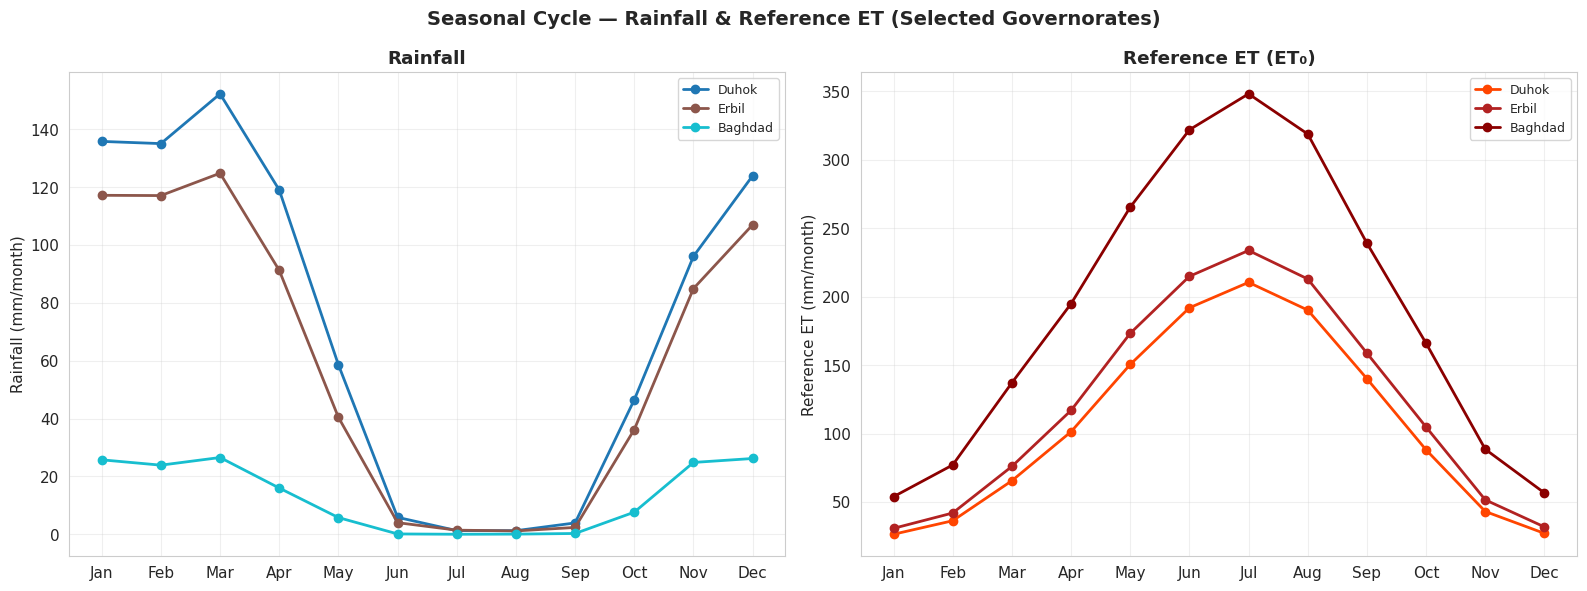

• Northern governorates receive 3-5x more winter rainfall than southern ones.
• ET₀ peaks Jun-Aug at 150-300 mm/month — when rainfall is near zero.
• The overlap between supply and demand months is minimal in all three zones.


In [ ]:
# =============================================================================
# SEASONAL CYCLE — RAINFALL & REFERENCE ET SIDE BY SIDE
# =============================================================================
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Seasonal Cycle — Rainfall & Reference ET (Selected Governorates)',
             fontsize=14, fontweight='bold')

colors      = plt.cm.tab10(np.linspace(0, 1, len(representatives)))
warm_colors = ['#FF4500', '#B22222', '#8B0000']   # orangered → darkred

# --- Rainfall (left) ---
ax1 = axes[0]
for gov, color in zip(representatives, colors):
    ax1.plot(range(1, 13), rain_clim[gov].values, 'o-', color=color,
             linewidth=2, markersize=6, label=gov)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_ylabel('Rainfall (mm/month)')
ax1.set_title('Rainfall', fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Reference ET (right) ---
ax2 = axes[1]
for gov, color in zip(representatives, warm_colors):   # ← warm_colors here
    ax2.plot(range(1, 13), ret_clim[gov].values, 'o-', color=color,
             linewidth=2, markersize=6, label=gov)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names)
ax2.set_ylabel('Reference ET (mm/month)')
ax2.set_title('Reference ET (ET\u2080)', fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\u2022 Northern governorates receive 3-5x more winter rainfall than southern ones.")
print("\u2022 ET\u2080 peaks Jun-Aug at 150-300 mm/month — when rainfall is near zero.")
print("\u2022 The overlap between supply and demand months is minimal in all three zones.")

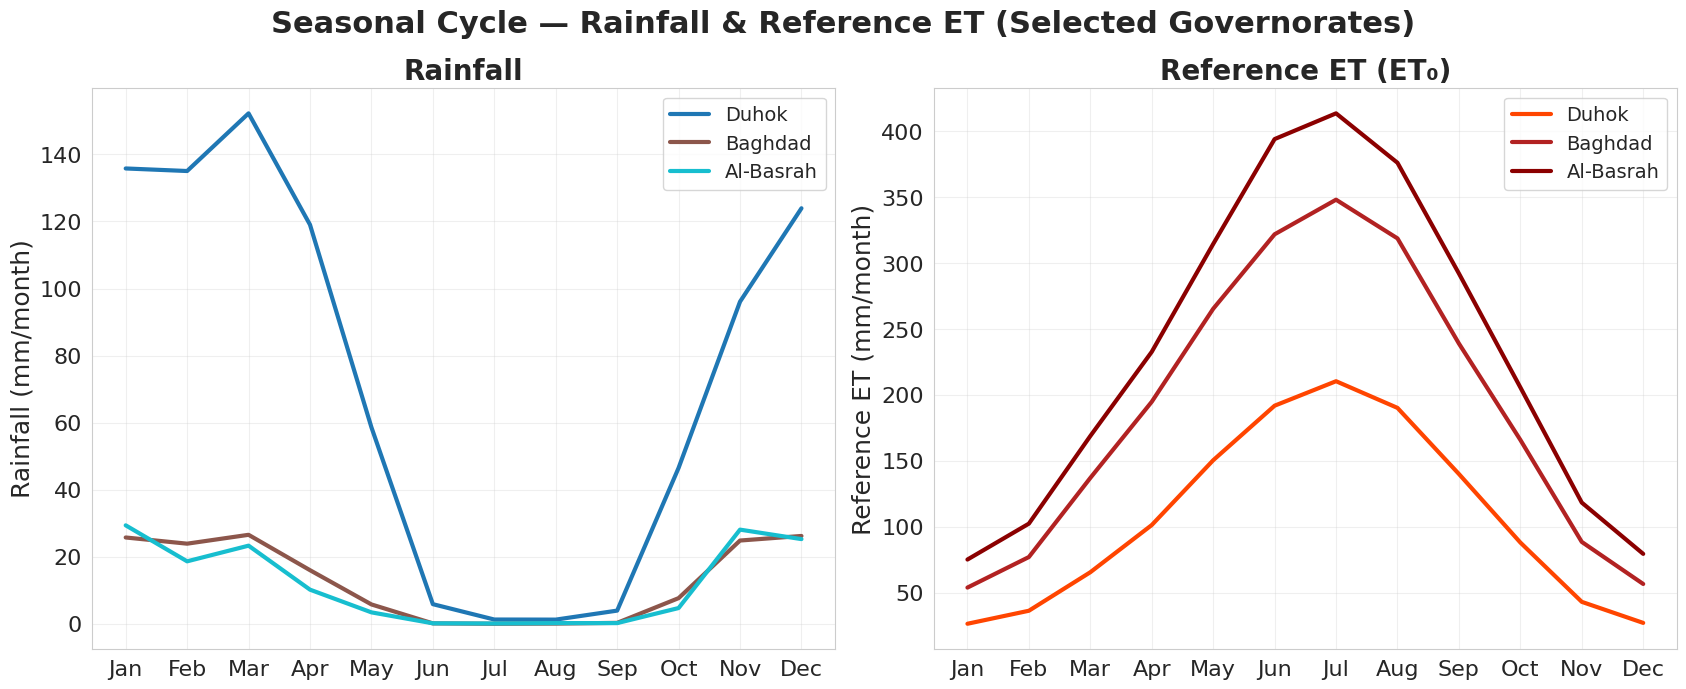

Northern governorates receive 3-5x more winter rainfall than southern ones.
ET₀ peaks Jun-Aug at 150-300 mm/month — when rainfall is near zero.
The overlap between supply and demand months is minimal in all three zones.


In [ ]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Seasonal Cycle — Rainfall & Reference ET (Selected Governorates)',
             fontsize=22, fontweight='bold')

representatives = ['Duhok', 'Baghdad', 'Al-Basrah']
colors      = plt.cm.tab10(np.linspace(0, 1, len(representatives)))
warm_colors = ['#FF4500', '#B22222', '#8B0000']   # orangered → darkred

# Helper: a real "speech bubble" callout — a rounded box with a solid wedge tail
# pointing at the data, instead of a thin arrow + plain text box.
def speech_bubble(ax, text, xy_point, xytext, fontsize=14):
    ax.annotate(
        text,
        xy=xy_point, xytext=xytext,
        fontsize=fontsize, fontweight='bold', ha='center', va='center', color='#202020',
        bbox=dict(boxstyle='round,pad=0.7', fc='#EAEAEA', ec='#202020', lw=1.6),
        arrowprops=dict(arrowstyle='wedge,tail_width=0.9', fc='#EAEAEA', ec='#202020', lw=1.6),
        zorder=10,
    )

# --- Rainfall (left) ---
ax1 = axes[0]
for gov, color in zip(representatives, colors):
    ax1.plot(range(1, 13), rain_clim[gov].values, '-', color=color,
              linewidth=3, label=gov)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names, fontsize=16)
ax1.set_ylabel('Rainfall (mm/month)', fontsize=18)
ax1.set_title('Rainfall', fontweight='bold', fontsize=20)
ax1.legend(fontsize=14, loc='upper right')
ax1.tick_params(axis='y', labelsize=16)
ax1.grid(True, alpha=0.3)

# Speech-bubble callout (replaces the old arrow + yellow box)
#ymin1, ymax1 = ax1.get_ylim()
#speech_bubble(ax1,
              #"Northern governorates receive\n3\u20135x more winter rainfall\nthan southern ones",
              #xy_point=(6, ymin1 + 0.05 * (ymax1 - ymin1)),
              #xytext=(6.3, ymin1 + 0.55 * (ymax1 - ymin1)))

# --- Reference ET (right) ---
ax2 = axes[1]
for gov, color in zip(representatives, warm_colors):
    ax2.plot(range(1, 13), ret_clim[gov].values, '-', color=color,
              linewidth=3, label=gov)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names, fontsize=16)
ax2.set_ylabel('Reference ET (mm/month)', fontsize=18)
ax2.set_title('Reference ET (ET₀)', fontweight='bold', fontsize=20)
ax2.legend(fontsize=14, loc='upper right')
ax2.tick_params(axis='y', labelsize=16)
ax2.grid(True, alpha=0.3)

# Speech-bubble callout (replaces the old plain text box)
#ymin2, ymax2 = ax2.get_ylim()
#speech_bubble(ax2,
              #"ET₀ peaks Jun\u2013Aug at 150\u2013300 mm/month\n\u2014 when rainfall is near zero",
              #xy_point=(9, ymin2 + 0.45 * (ymax2 - ymin2)),
              #xytext=(9.3, ymin2 + 0.20 * (ymax2 - ymin2)))

plt.tight_layout()
plt.show()

print("Northern governorates receive 3-5x more winter rainfall than southern ones.")
print("ET₀ peaks Jun-Aug at 150-300 mm/month — when rainfall is near zero.")
print("The overlap between supply and demand months is minimal in all three zones.")

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
The mean monthly climatology of rainfall (left) and Reference ET (right) for three governorates spanning Iraq's north–south climate gradient.
>
>**What works well:**
Using identical colors for the same governorate across both panels allows the reader to track one location across both variables without re-reading the legend — a simple but powerful device for multi-panel comparison. The consistent x-axis (calendar months) makes the seasonal offset visible at a glance.
>
>**What to watch out for:**
The y-axes are scaled independently (rainfall 0–150 mm, ET 0–300 mm). This is correct — the goal is to show shape, not magnitude. But a reader who does not check the y-axis labels may incorrectly conclude that the curves are similar in size. A shared y-axis would be factually misleading; independent axes are right here but should be clearly labelled.
>
>**What could be improved:**
Adding a grey shading to the months where ET > rainfall on each governorate's panel would directly encode the water deficit period — the key message of the chart — without requiring mental subtraction from the reader.
>
>---
>
>🔔 **QUIZ**
>
>**Erbil receives its peak rainfall in January–March. ET₀ peaks in June–August.**
>**In which months does a water surplus exist for Erbil, and for how many months does deficit persist?**
>
>A) Surplus: Jun–Aug (3 months) · Deficit: Sep–May (9 months)
>
>B) Surplus: Nov–Mar (5 months) · Deficit: Apr–Oct (7 months)
>
>C) Surplus: Jan–Mar (3 months) · Deficit: Apr–Dec (9 months)
>
>D) No surplus exists — ET₀ exceeds rainfall in all months

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ B — Surplus (P > ET₀): November–March (~5 months). Deficit (ET₀ > P): April–October (~7 months).**

*From the climatology, Erbil's surplus months are November–March — for example, January rainfall ~117 mm/month vs ET₀ ~31 mm/month (surplus +86 mm). From April onward, ET₀ rises steeply while rainfall collapses.*

*The structural deficit lasts ~7 months (April–October), covering the entire summer cropping window. Crucially, January–March are surplus months — this is precisely the period when Iraq's dominant rainfed winter cereals (wheat, barley) complete most of their vegetative growth. Rainfed cereal farming is viable in northern Iraq because the crop season aligns with the surplus period.*

</details>

>>💬 **FORUM**
>>
>>The demo shows Duhok, Erbil, and Baghdad. Choose **three different governorates** — one from the south (e.g. Al-Basrah, Al-Muthanna), one central, one northern — and reproduce this chart.
>>
>>How does the length of the deficit period compare across your three selections? Does the north–south pattern hold for ET₀ or only for rainfall?
>>
>>Post your figure with a two-sentence interpretation.

---

## 6a. Monthly Climatology Heatmap — Rainfall & Reference ET

A paired heatmap encodes 18 × 12 = 216 values per variable in a single figure. The colormap choice matters: sequential `(YlGnBu)` for rainfall, sequential-warm `(YlOrRd)` for ET. Both are correct because both variables are non-negative magnitudes with no meaningful midpoint.

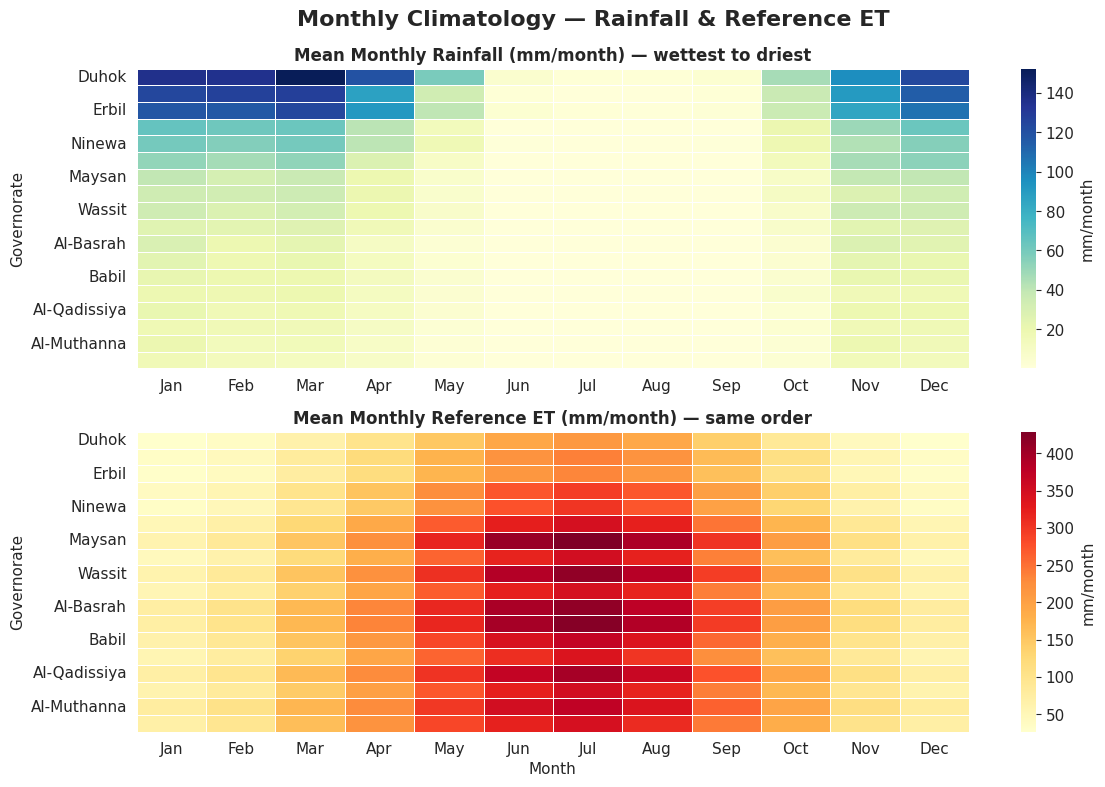

• Rainfall: concentrated Nov-Apr, near zero Jun- Sep, strong north-south gradient.
• ET₀: peaks Jun-3Aug everywhere, weakest in the cooler north.
• The two panels are anti-correlated in time — the central finding of Iraq's water stress.


In [ ]:
# =============================================================================
# MONTHLY CLIMATOLOGY HEATMAP — RAINFALL & REFERENCE ET
# =============================================================================

# Sort governorates wettest-to-driest (same order in both panels)
sorted_govs = rain_stats.sort_values('mean', ascending=False).index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Monthly Climatology — Rainfall & Reference ET',
             fontsize=16, fontweight='bold')

sns.heatmap(rain_clim[sorted_govs].T, ax=axes[0], cmap='YlGnBu',
            annot=False, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': 'mm/month'}) # Removed numbers from heatmap
axes[0].set_title('Mean Monthly Rainfall (mm/month) — wettest to driest', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Governorate')
axes[0].set_xlabel('')

sns.heatmap(ret_clim[sorted_govs].T, ax=axes[1], cmap='YlOrRd',
            annot=False, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': 'mm/month'}) # Removed numbers from heatmap
axes[1].set_title('Mean Monthly Reference ET (mm/month) — same order', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Governorate')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

print("\u2022 Rainfall: concentrated Nov-Apr, near zero Jun- Sep, strong north-south gradient.")
print("\u2022 ET\u2080: peaks Jun-3Aug everywhere, weakest in the cooler north.")
print("\u2022 The two panels are anti-correlated in time — the central finding of Iraq's water stress.")

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
The 18 × 12 climatology matrix for both variables. Rows are governorates sorted wettest-to-driest; columns are calendar months.
>
>**What works well:**
Using the same governorate sort order in both panels is the critical design decision here. The reader's eye can scan vertically down any month column and compare rainfall vs ET for the same governorate without searching. Scanning down the June column: the rainfall row is pale yellow everywhere; the ET row is deep red everywhere. The mismatch is instantaneous.
>
>**What to watch out for:**
The annotation (`fmt='.0f'`) prints rounded integers, which is appropriate for monthly averages. But with 18 × 12 = 216 cells and font size 8, the numbers are small. On a standard laptop screen, the ET panel numbers may be illegible. Always check your figure at export resolution, not just on-screen.
>
>**What could be improved:**
For a report or presentation, consider showing only the rainfall heatmap with a second panel showing the *deficit* (ET − rainfall), using a diverging colormap. This collapses two panels into one message and removes the cognitive arithmetic the reader currently has to do.
>
>---
>
>🔔 **QUIZ**
>
>**Both heatmaps use sequential colormaps (`YlGnBu` and `YlOrRd`). If you replaced the rainfall heatmap with one showing *rainfall anomaly* (Z-score), which colormap family would be required and why?**

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ Diverging (e.g. `RdYlBu`), centered at Z = 0.**

*A Z-score has a meaningful midpoint (zero = exactly average). Values above and below zero are both informative: positive = wetter than average, negative = drier. A sequential colormap maps low values to light and high to dark, which would encode "dry" as light and "wet" as dark — losing the direction entirely for values near zero. A diverging colormap centered at zero correctly encodes both directions of deviation from the mean.*

</details>

>>💬 **FORUM**
>>
>>The demo plots the climatology for all 18 governorates. Compute and plot a **deficit heatmap**: subtract mean monthly rainfall from mean monthly ET₀ for each governorate and month.
>>
>>Use a diverging colormap (e.g. `RdYlBu_r`) centered at zero, where red = deficit (ET₀ > P) and blue = surplus (P > ET₀).
>>
>>Which months show a surplus anywhere in Iraq, and which governorates show the longest surplus period? Post your code and figure.

---

## 6b. Trend Visualization

Trend results from the Mann-Kendall test (computed in Lesson 01) are stored in <code>rain_trend.csv</code> and <code>ret_trend.csv</code>. Sen's slope is the median of all pairwise slopes - a robust, non-parametric estimator that is insensitive to single outlier years. The significance threshold used here is p < 0.05 (two-tailed).

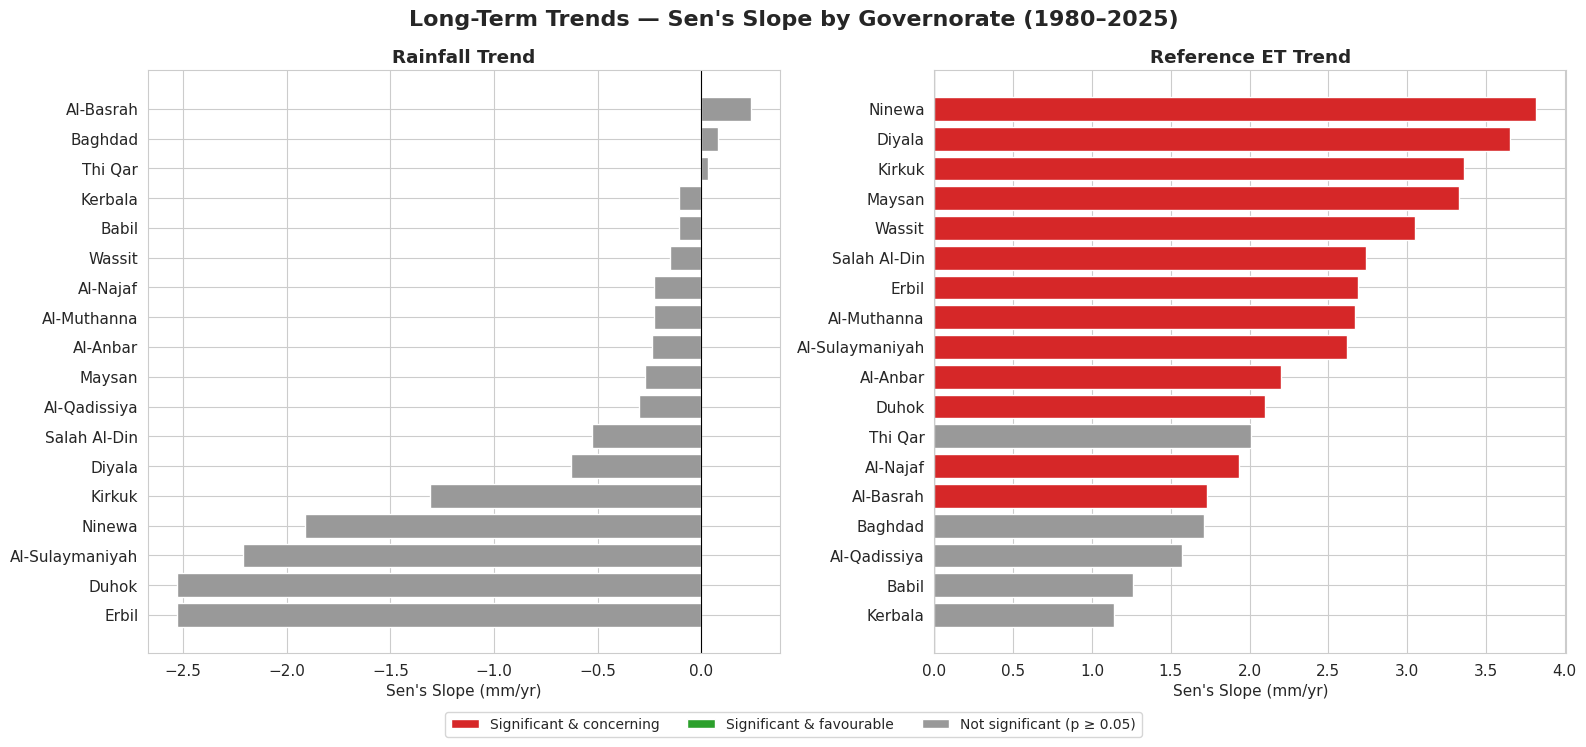

Significant rainfall trends: 0/18 governorates
Significant ET trends:       13/18 governorates

• Most rainfall trends are not statistically significant at p < 0.05 over 1980–2025.
• ET trends are predominantly significant and positive — rising atmospheric demand
  is the more robust climate signal in this dataset.


In [ ]:
# =============================================================================
# TREND VISUALIZATION — SEN'S SLOPE (RAINFALL & REFERENCE ET)
# =============================================================================

ret_trend = pd.read_csv(_resolve_csv(data_folder, 'ret_trend.csv'), index_col='Governorate')

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, n_gov * 0.4)))
fig.suptitle("Long-Term Trends — Sen's Slope by Governorate (1980–2025)",
             fontsize=16, fontweight='bold')

def _trend_colors(slopes, pvals, var='rain'):
    # Colour coding:
    #   Rainfall:  significant negative = red (less rain, concerning)
    #              significant positive = green (more rain, favourable)
    #   ET:        significant positive = red (more demand, concerning)
    #              significant negative = green (less demand, favourable)
    #   Not significant (p >= 0.05) = grey
    colors = []
    for s, p in zip(slopes, pvals):
        if p >= 0.05:
            colors.append('#999999')
        elif var == 'rain':
            colors.append('#d62728' if s < 0 else '#2ca02c')
        else:
            colors.append('#d62728' if s > 0 else '#2ca02c')
    return colors

# --- Rainfall ---
ax1 = axes[0]
slopes_r = rain_trend['Slope (mm/yr)'].sort_values()
pvals_r  = rain_trend.loc[slopes_r.index, 'p-value']
ax1.barh(slopes_r.index, slopes_r.values,
         color=_trend_colors(slopes_r, pvals_r, 'rain'), edgecolor='white')
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_xlabel("Sen's Slope (mm/yr)")
ax1.set_title('Rainfall Trend', fontweight='bold')

# --- Reference ET ---
ax2 = axes[1]
slopes_e = ret_trend['Slope (mm/yr)'].sort_values()
pvals_e  = ret_trend.loc[slopes_e.index, 'p-value']
ax2.barh(slopes_e.index, slopes_e.values,
         color=_trend_colors(slopes_e, pvals_e, 'et'), edgecolor='white')
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel("Sen's Slope (mm/yr)")
ax2.set_title('Reference ET Trend', fontweight='bold')

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(facecolor='#d62728', label='Significant & concerning'),
             Patch(facecolor='#2ca02c', label='Significant & favourable'),
             Patch(facecolor='#999999', label='Not significant (p \u2265 0.05)')],
    loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04)
)
plt.tight_layout()
plt.show()

sig_rain = (rain_trend['p-value'] < 0.05).sum()
sig_et   = (ret_trend['p-value']  < 0.05).sum()
print(f"Significant rainfall trends: {sig_rain}/{n_gov} governorates")
print(f"Significant ET trends:       {sig_et}/{n_gov} governorates")
print("\n\u2022 Most rainfall trends are not statistically significant at p < 0.05 over 1980\u20132025.")
print("\u2022 ET trends are predominantly significant and positive \u2014 rising atmospheric demand")
print("  is the more robust climate signal in this dataset.")


>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
The slope (mm/yr) for rainfall and Reference ET for all 18 governorates, coloured by statistical significance and direction.
>
>**What works well:**
Encoding three attributes simultaneously (direction, magnitude, significance) into one bar chart is efficient. The color encodes significance + direction; bar length encodes magnitude; the vertical line at zero provides a reference without adding clutter. The asymmetric color rules (red = concerning) are different for the two variables and are documented in the code comment — critical for reproducibility.
>
>**What to watch out for:**
Statistical significance (p < 0.05) is not the same as practical significance. Al-Basrah has the smallest significant ET slope in this dataset: +1.73 mm/yr. Over 46 years that is 1.73 × 46 = ~ 80 mm cumulative — about 2.9% of its mean annual ET (~ 2770 mm). Statistically robust, but modest as a fraction of annual demand. Always pair a trend chart with the actual cumulative magnitude to avoid overstating findings.
>
>**What could be improved:**
Add a secondary annotation showing the total cumulative change over the analysis period (slope × years). This converts the abstract mm/yr unit into a concrete number the reader can assess for practical relevance.
>
>---
>
>🔔 **DISCUSS**
>
>**Most rainfall trends are grey (not significant), while most ET trends are red (significant).**
>**A student concludes: *"Rainfall is not changing in Iraq."***
>**What is wrong with this conclusion, and what would be the correct statistical statement?**
>
>Post your answer in the course forum before reading below.

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ Absence of evidence is not evidence of absence.**

*A non-significant result means the test did not detect a trend at p < 0.05 given the available data — it does not mean no trend exists. Rainfall is highly variable — CV ranges from ~22% in the wetter north (Duhok, Erbil) to ~40% in the arid south (Al-Basrah, Thi Qar) — which reduces statistical power, particularly where interannual variability is largest relative to the mean. The correct statement is: "No statistically significant trend in annual rainfall was detected for most governorates over 1980–2025 at the p < 0.05 level." This is meaningfully different from claiming rainfall is stable.*

</details>

>>💬 **FORUM**
>>
>>The trend chart shows direction and significance but not the trend *over time*. Pick **two governorates** — one with a significant ET trend and one without — and plot their **annual ET time series** with the slope line overlaid (use `ret_annual`).
>>
>>Does the fitted line look convincing visually? What do outlier years do to your perception of the trend?
>>
>>Post your figure and a critical comment on what the chart does and does not show.

---

## 6c.  Rainfall Anomaly — Space × Time Heatmap

Standardising annual rainfall by governorate (Z-score = (x − mean) / std) removes the north–south magnitude difference and reveals the temporal pattern: which years were dry or wet, and were dry years synchronous across the country?

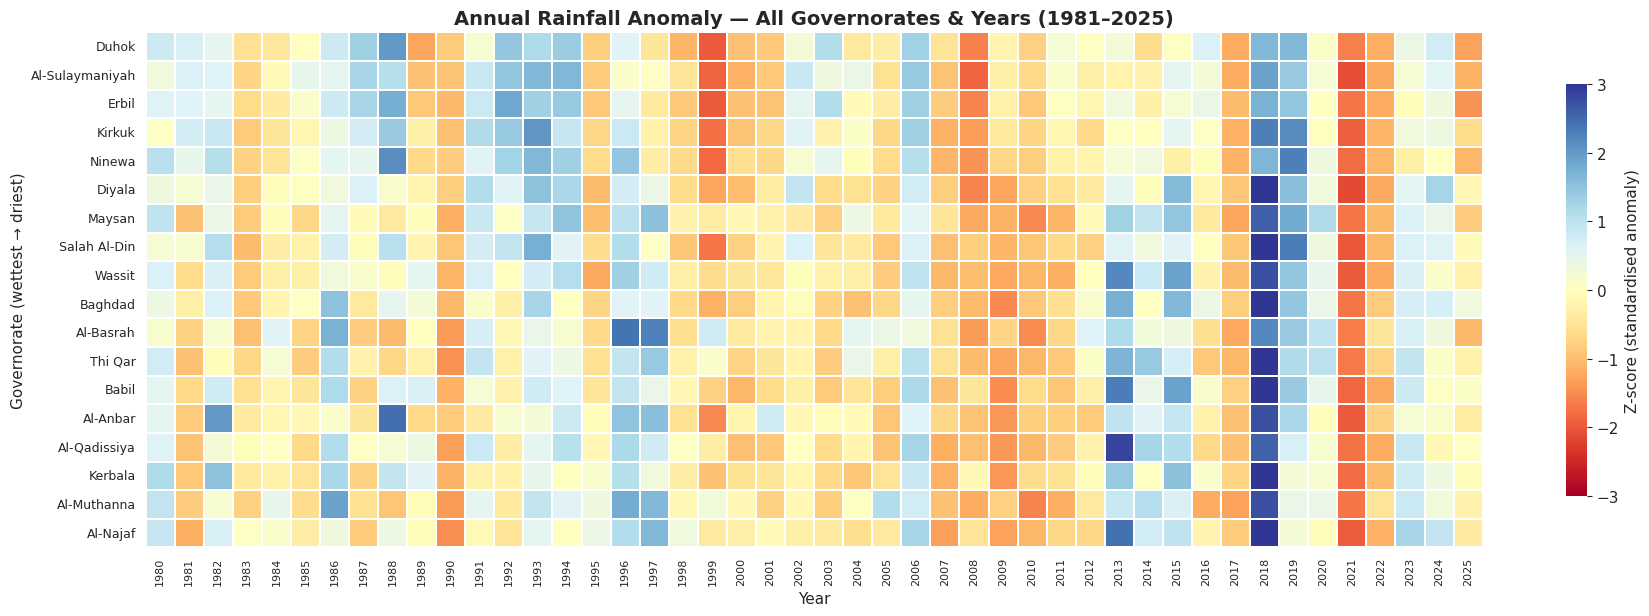

Five driest years (country-wide mean Z-score):
  2021: Z = -1.85
  2008: Z = -1.12
  1990: Z = -1.11
  2017: Z = -1.04
  2022: Z = -1.02

Five wettest years:
  2018: Z = +2.68
  2019: Z = +1.35
  2013: Z = +1.14
  1996: Z = +1.06
  1993: Z = +1.03


In [ ]:
# =============================================================================
# RAINFALL ANOMALY — SPACE × TIME HEATMAP
# =============================================================================

rain_annual_df = pd.read_csv(_resolve_csv(data_folder, 'rain_annual.csv'),
                              index_col=0, parse_dates=True)

# Standardise by governorate (remove the north-south magnitude gradient)
rain_anomaly = (rain_annual_df - rain_annual_df.mean()) / rain_annual_df.std()

# Order: wettest governorate at top
sorted_govs_wet = rain_stats.sort_values('mean', ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(max(16, len(rain_anomaly) * 0.4),
                                 max(6, n_gov * 0.35)))

heatmap_data = rain_anomaly[sorted_govs_wet].T.copy()
heatmap_data.columns = rain_anomaly.index.year

sns.heatmap(heatmap_data, cmap='RdYlBu', center=0, vmin=-3, vmax=3,
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Z-score (standardised anomaly)', 'shrink': 0.8},
            xticklabels=True, yticklabels=True)

ax.set_title('Annual Rainfall Anomaly — All Governorates & Years (1981–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Governorate (wettest → driest)')
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

# Country-wide extreme years
country_avg = rain_anomaly.mean(axis=1)
print("Five driest years (country-wide mean Z-score):")
for yr, val in country_avg.nsmallest(5).items():
    print(f"  {yr.year}: Z = {val:.2f}")

print("\nFive wettest years:")
for yr, val in country_avg.nlargest(5).items():
    print(f"  {yr.year}: Z = {val:+.2f}")

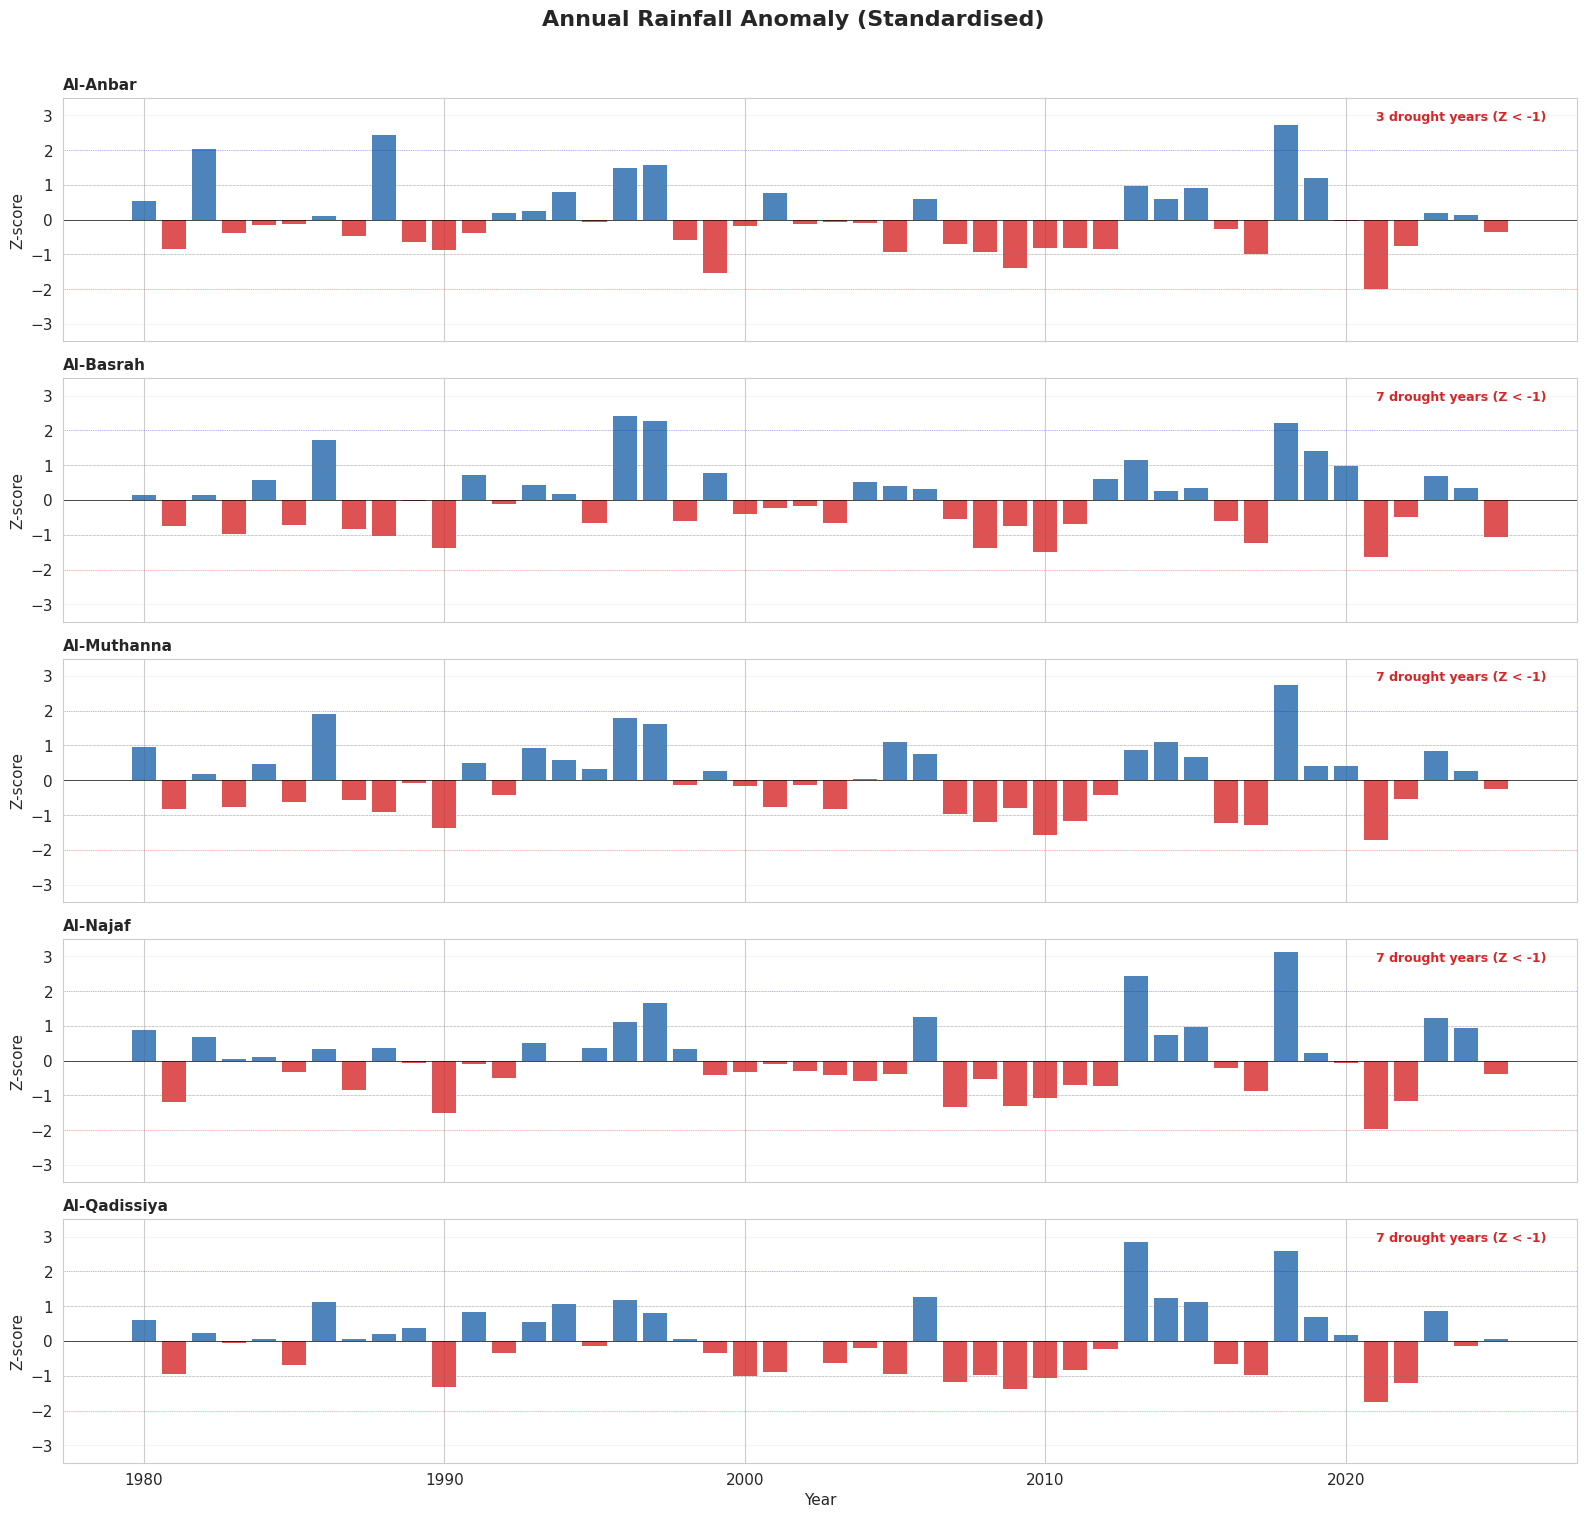

💡 Red bars = below-average rainfall; Blue bars = above-average
   Dashed lines at ±1σ (moderate); dotted lines at ±2σ (extreme)


In [ ]:
# =============================================================================
# ANNUAL ANOMALY BAR CHARTS — SELECTED GOVERNORATES
# =============================================================================

# Updated representatives list to show 5 governorates
representatives = governorates[:5]

fig, axes = plt.subplots(len(representatives), 1,
                         figsize=(16, 3 * len(representatives)), sharex=True)
fig.suptitle('Annual Rainfall Anomaly (Standardised)',
             fontsize=16, fontweight='bold', y=1.01)

if len(representatives) == 1:
    axes = [axes]

for idx, gov in enumerate(representatives):
    ax = axes[idx]
    anomaly = rain_anomaly[gov]
    years = anomaly.index.year

    # Colour by sign
    colors = ['#d62728' if v < 0 else '#2166ac' for v in anomaly.values]

    ax.bar(years, anomaly.values, color=colors, width=0.8,
           edgecolor='none', alpha=0.8)
    ax.axhline(y=0,  color='black', linewidth=0.5)
    ax.axhline(y=-1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axhline(y=1,  color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axhline(y=-2, color='red',  linewidth=0.5, linestyle=':',  alpha=0.5)
    ax.axhline(y=2,  color='blue', linewidth=0.5, linestyle=':',  alpha=0.5)
    ax.set_ylabel('Z-score')
    ax.set_title(gov, fontsize=11, fontweight='bold', loc='left')
    ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.2, axis='y')

    # Count drought years
    n_drought = (anomaly < -1).sum()
    ax.text(0.98, 0.95, f'{n_drought} drought years (Z < -1)',
            transform=ax.transAxes, fontsize=9, ha='right', va='top',
            color='#d62728', fontweight='bold')

axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

print("\U0001f4a1 Red bars = below-average rainfall; Blue bars = above-average")
print("   Dashed lines at \u00b11\u03c3 (moderate); dotted lines at \u00b12\u03c3 (extreme)")

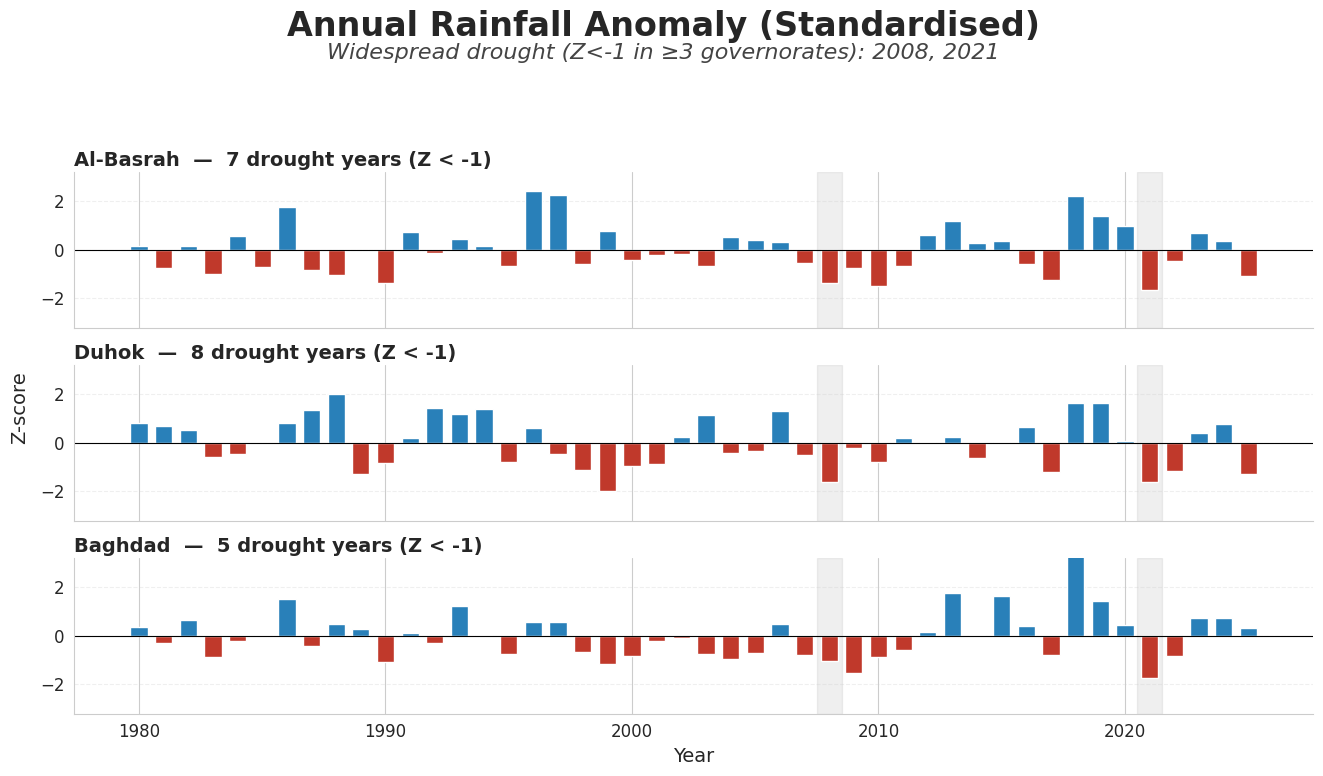

In [ ]:
# =============================================================================
# SLIDE-READY VERSION — Annual Rainfall Anomaly per Governorate (5 panels)
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

govs_to_plot = ['Al-Basrah', 'Duhok', 'Baghdad']
years = rain_anomaly.index.year

# Years where at least 3 of the 5 governorates are simultaneously in drought (Z < -1) —
# shading these across every panel turns five separate charts into one shared story.
drought_mask = rain_anomaly[govs_to_plot] < -1
shared_drought_years = years[drought_mask.sum(axis=1) >= 3].tolist()
subtitle = (f"Widespread drought (Z<-1 in \u22653 governorates): "
            f"{', '.join(str(y) for y in shared_drought_years)}")

fig, axes = plt.subplots(len(govs_to_plot), 1, figsize=(13.33, 7.5), sharex=True)

fig.suptitle('Annual Rainfall Anomaly (Standardised)', fontsize=24, fontweight='bold', y=1.03)
fig.text(0.5, 0.965, subtitle, ha='center', fontsize=16, style='italic', color='#444444')

for ax, gov in zip(axes, govs_to_plot):
    z = rain_anomaly[gov].to_numpy()
    n_drought = int((z < -1).sum())

    colors = np.where(z < 0, '#c0392b', '#2980b9')
    ax.bar(years, z, color=colors, width=0.7)
    ax.axhline(0, color='black', linewidth=0.8)

    for y in shared_drought_years:
        ax.axvspan(y - 0.5, y + 0.5, color='grey', alpha=0.12, zorder=0)

    ax.set_ylim(-3.2, 3.2)
    ax.set_yticks([-2, 0, 2])
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # One consolidated title instead of a separate boxed annotation
    ax.set_title(f'{gov}  —  {n_drought} drought years (Z < -1)',
                 loc='left', fontsize=14, fontweight='bold', pad=4)

axes[-1].set_xlabel('Year', fontsize=14)
axes[-1].tick_params(axis='x', labelsize=12)
fig.text(0.01, 0.5, 'Z-score', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.02, 0, 1, 0.93])
plt.savefig('rainfall_anomaly_slide.png', dpi=150, bbox_inches='tight')
plt.show()

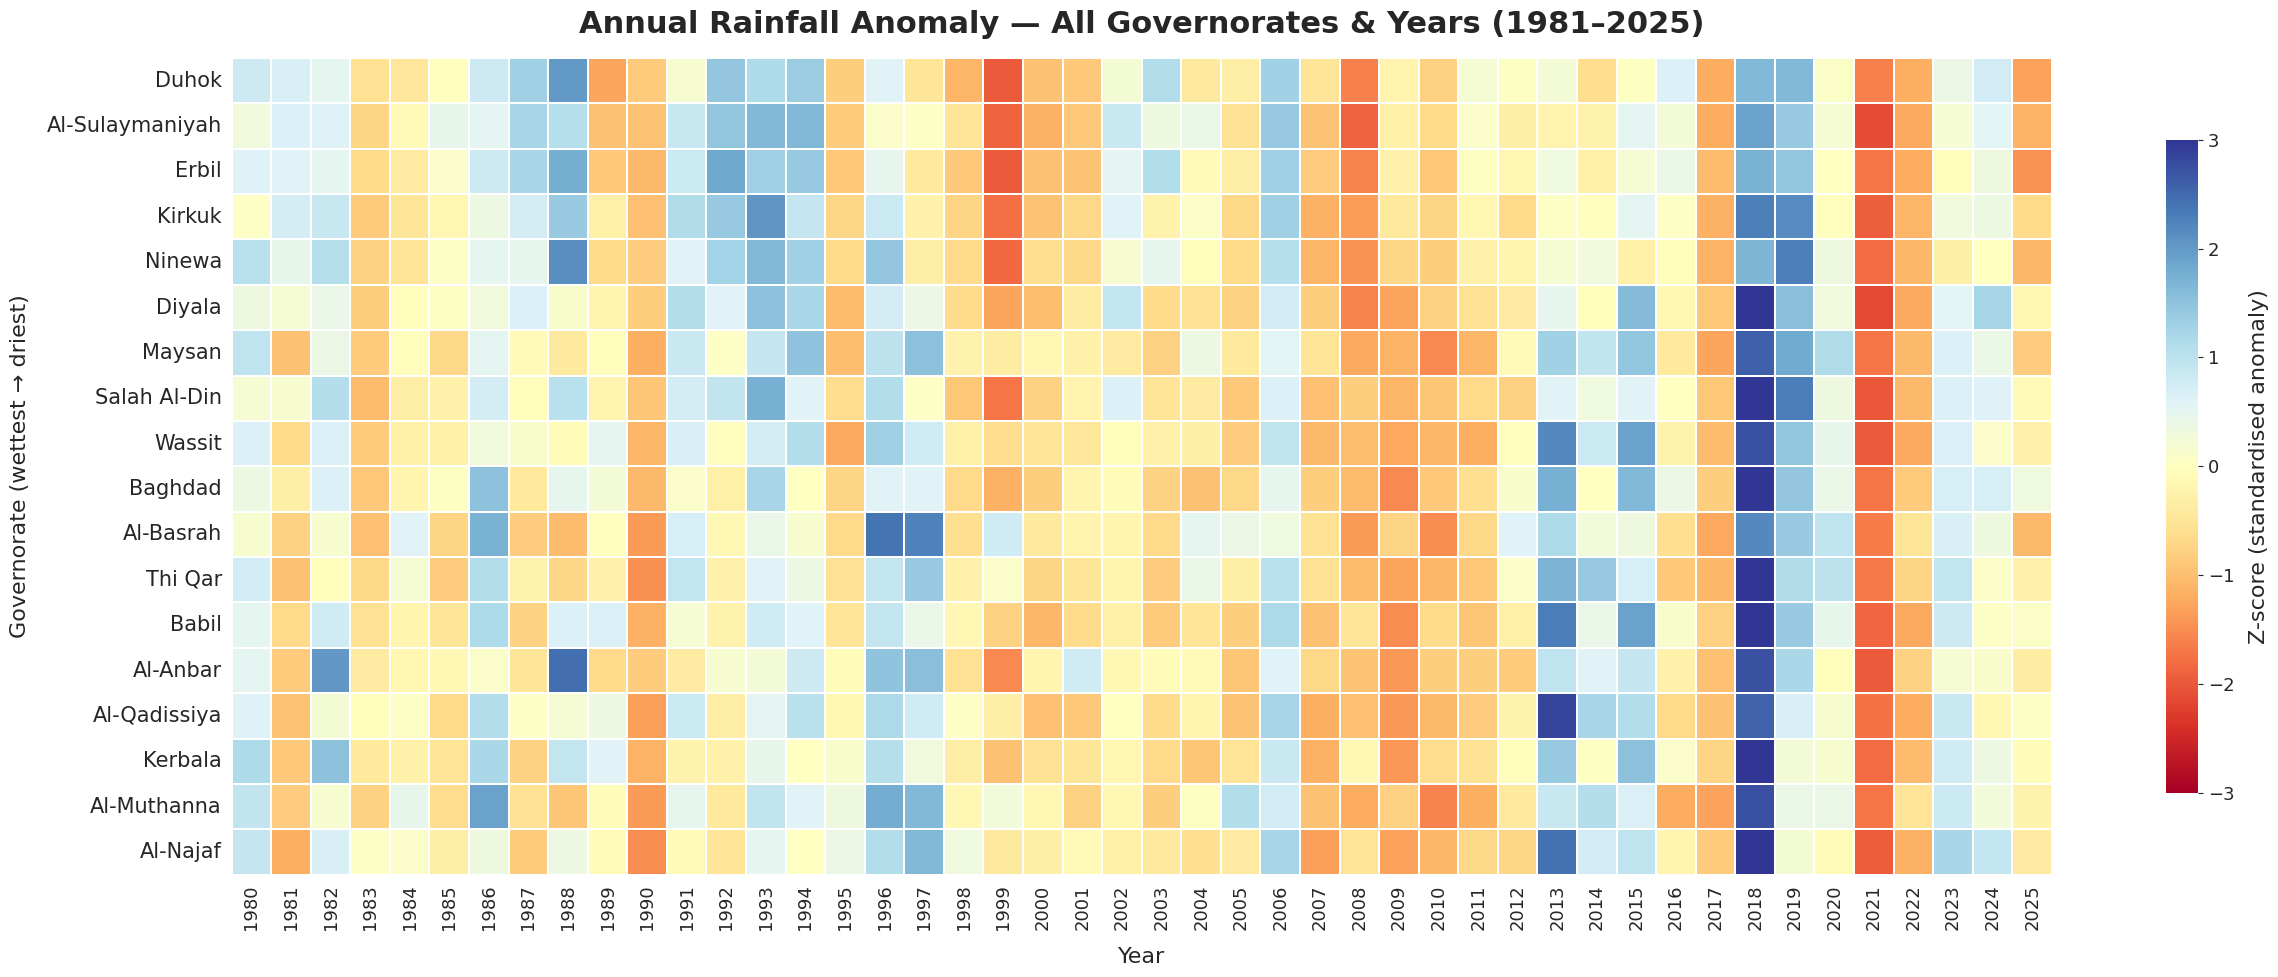

Five driest years (country-wide mean Z-score):
  2021: Z = -1.85
  2008: Z = -1.12
  1990: Z = -1.11
  2017: Z = -1.04
  2022: Z = -1.02

Five wettest years:
  2018: Z = +2.68
  2019: Z = +1.35
  2013: Z = +1.14
  1996: Z = +1.06
  1993: Z = +1.03


In [ ]:
# =============================================================================
# RAINFALL ANOMALY — SPACE × TIME HEATMAP
# =============================================================================

rain_annual_df = pd.read_csv(_resolve_csv(data_folder, 'rain_annual.csv'),
                              index_col=0, parse_dates=True)

# Standardise by governorate (remove the north-south magnitude gradient)
rain_anomaly = (rain_annual_df - rain_annual_df.mean()) / rain_annual_df.std()

# Order: wettest governorate at top
sorted_govs_wet = rain_stats.sort_values('mean', ascending=False).index.tolist()

# Bigger canvas to give the larger fonts room to breathe
fig, ax = plt.subplots(figsize=(max(22, len(rain_anomaly) * 0.55),
                                 max(9, n_gov * 0.55)))

heatmap_data = rain_anomaly[sorted_govs_wet].T.copy()
heatmap_data.columns = rain_anomaly.index.year

sns.heatmap(heatmap_data, cmap='RdYlBu', center=0, vmin=-3, vmax=3,
            linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8},  # label set manually below for font control
            xticklabels=True, yticklabels=True)

ax.set_title('Annual Rainfall Anomaly — All Governorates & Years (1981–2025)',
             fontsize=22, fontweight='bold', pad=18)
ax.set_xlabel('Year', fontsize=16, labelpad=12)
ax.set_ylabel('Governorate (wettest → driest)', fontsize=16, labelpad=12)
ax.tick_params(axis='x', rotation=90, labelsize=13)
ax.tick_params(axis='y', labelsize=15)

# Colorbar (the Z-score scale) — label + tick numbers enlarged
cbar = ax.collections[0].colorbar
cbar.set_label('Z-score (standardised anomaly)', fontsize=16, labelpad=10)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.show()

# Country-wide extreme years
country_avg = rain_anomaly.mean(axis=1)
print("Five driest years (country-wide mean Z-score):")
for yr, val in country_avg.nsmallest(5).items():
    print(f"  {yr.year}: Z = {val:.2f}")

print("\nFive wettest years:")
for yr, val in country_avg.nlargest(5).items():
    print(f"  {yr.year}: Z = {val:+.2f}")

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
Annual standardised rainfall anomalies for all 18 governorates and all years, as a governorate × year matrix. Blue = wetter than average; red = drier. Rows are sorted from wettest (top) to driest (bottom) governorate by long-term mean.
>
>**What works well:**
The diverging colormap (`RdYlBu`) centred at zero is the correct choice for anomaly data — both directions of deviation from the mean carry equal informational weight. Vertical stripes (columns of the same colour) reveal years when drought or surplus was country-wide. Horizontal stripes reveal governorates with persistently anomalous rainfall relative to their own mean.
>
>**What to watch out for:**
Z-scores are computed relative to each governorate's own mean and standard deviation. This removes the north–south magnitude gradient by design. The chart answers "was this year anomalous for this place?" not "how much rain fell?" A reader who forgets the standardisation may incorrectly interpret Duhok's blue cells as meaning "more rain than Al-Basrah" — they mean "more than Duhok's own average."
>
>**What could be improved:**
Overlay the country-wide mean Z-score as a bar chart below the heatmap (`sharex`). This lets the reader identify nationally synchronous drought years at a glance without mentally averaging across rows.
>
>---
>
>🔔 **QUIZ**
>
>**The heatmap uses a diverging colormap centred at Z = 0. If the same heatmap were redrawn using a sequential colormap (e.g. `YlGnBu`), what specific misreading would it produce?**

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ Below-average years would appear pale and above-average years dark — but both directions would lose their equal visual weight, making wet and dry deviations appear asymmetric.**

*With a sequential colormap, Z = −2 (severe drought) and Z = 0 (average) would look similar (both pale), while Z = +2 (very wet) would appear dark. A reader could easily mistake "light" as meaning "nothing happened" when it actually signals a severe deficit. The diverging palette, centred at white or yellow, makes both extremes equally salient.*

</details>

>>💬 **FORUM**
>>
>>The demo shows rainfall anomalies. Compute and plot the equivalent anomaly heatmap for **annual Reference ET** (standardise `ret_annual` by governorate).
>>
>>Compare the two heatmaps side by side. Are dry rainfall years (Z < −1) systematically associated with high ET anomalies (Z > +1)? What mechanism would explain such a relationship?
>>
>>Post your paired figures and interpretation.

---

## 6d. Aridity Index (P / ET₀)

The UNEP aridity index (AI = mean annual P / mean annual ET₀) classifies climates from hyper-arid (AI < 0.03) to humid (AI ≥ 0.65). It translates the separate rainfall and ET signals into a single, interpretable ratio. The pre-computed governorate means are in <code>ai_mean.csv</code>.

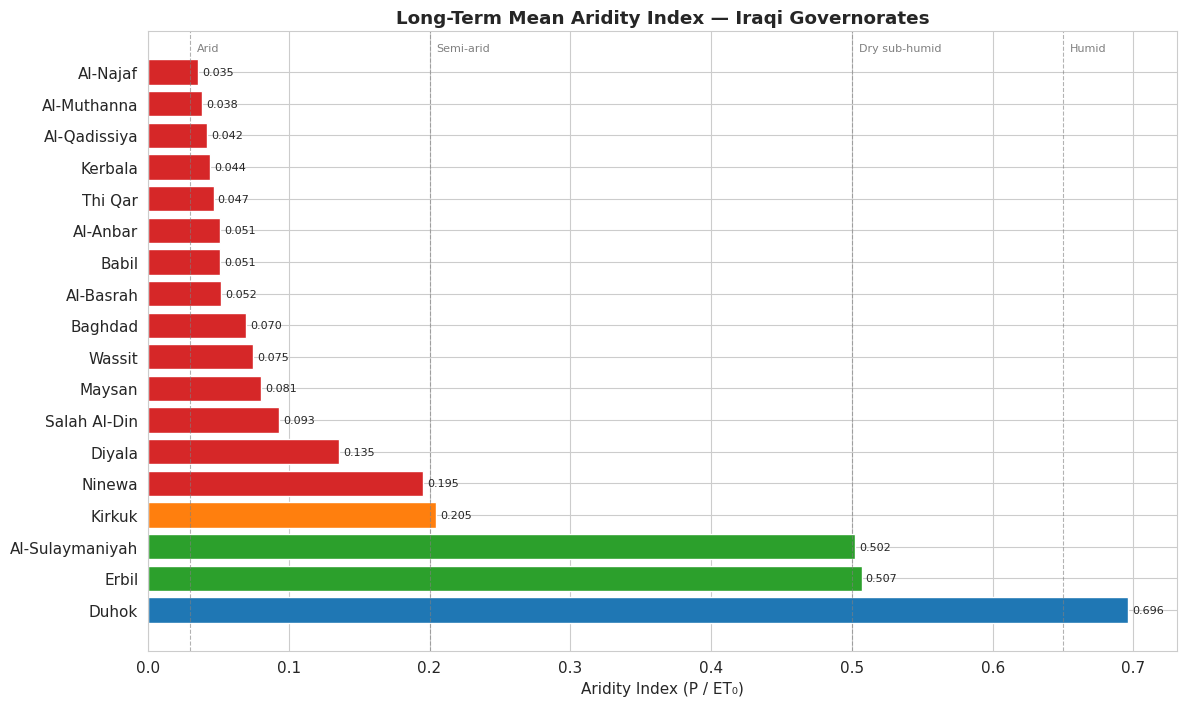

Aridity classification by governorate:
--------------------------------------------------
  Humid           : Duhok
  Dry sub-humid   : Erbil, Al-Sulaymaniyah
  Semi-arid       : Kirkuk
  Arid            : Ninewa, Diyala, Salah Al-Din, Maysan, Wassit, Baghdad, Al-Basrah, Babil, Al-Anbar, Thi Qar, Kerbala, Al-Qadissiya, Al-Muthanna, Al-Najaf


In [ ]:
# =============================================================================
# ARIDITY INDEX (P / ET₀) — BAR CHART WITH CLASSIFICATION THRESHOLDS
# =============================================================================

# ai_mean already loaded in cell 9 — one column of long-term mean AI per governorate
ai_series = ai_mean.iloc[:, 0].sort_values(ascending=False)

# UNEP aridity classification thresholds (Middleton & Thomas 1997)
ARIDITY_CLASSES = [
    (0.65, 'Humid',         '#1f77b4'),
    (0.50, 'Dry sub-humid', '#2ca02c'),
    (0.20, 'Semi-arid',     '#ff7f0e'),
    (0.03, 'Arid',          '#d62728'),
    (0.00, 'Hyper-arid',    '#8B0000'),
]

def aridity_class(ai):
    for threshold, label, _ in ARIDITY_CLASSES:
        if ai >= threshold:
            return label
    return 'Hyper-arid'

def aridity_color(ai):
    for threshold, _, color in ARIDITY_CLASSES:
        if ai >= threshold:
            return color
    return '#8B0000'

bar_colors = [aridity_color(v) for v in ai_series.values]

fig, ax = plt.subplots(figsize=(12, max(6, n_gov * 0.4)))
bars = ax.barh(ai_series.index, ai_series.values, color=bar_colors, edgecolor='white')

# Classification threshold lines
thresholds = [(0.65, 'Humid'), (0.50, 'Dry sub-humid'), (0.20, 'Semi-arid'), (0.03, 'Arid')]
for t, lbl in thresholds:
    ax.axvline(x=t, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.text(t + 0.005, ax.get_ylim()[1] * 0.98, lbl,
            fontsize=8, color='gray', va='top')

ax.set_xlabel('Aridity Index (P / ET\u2080)')
ax.set_title('Long-Term Mean Aridity Index — Iraqi Governorates', fontweight='bold')

# Value labels
for bar, val in zip(bars, ai_series.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Aridity classification by governorate:")
print("-" * 50)
for cls in ['Humid', 'Dry sub-humid', 'Semi-arid', 'Arid', 'Hyper-arid']:
    govs = [g for g, v in ai_series.items() if aridity_class(v) == cls]
    if govs:
        print(f"  {cls:16s}: {', '.join(govs)}")


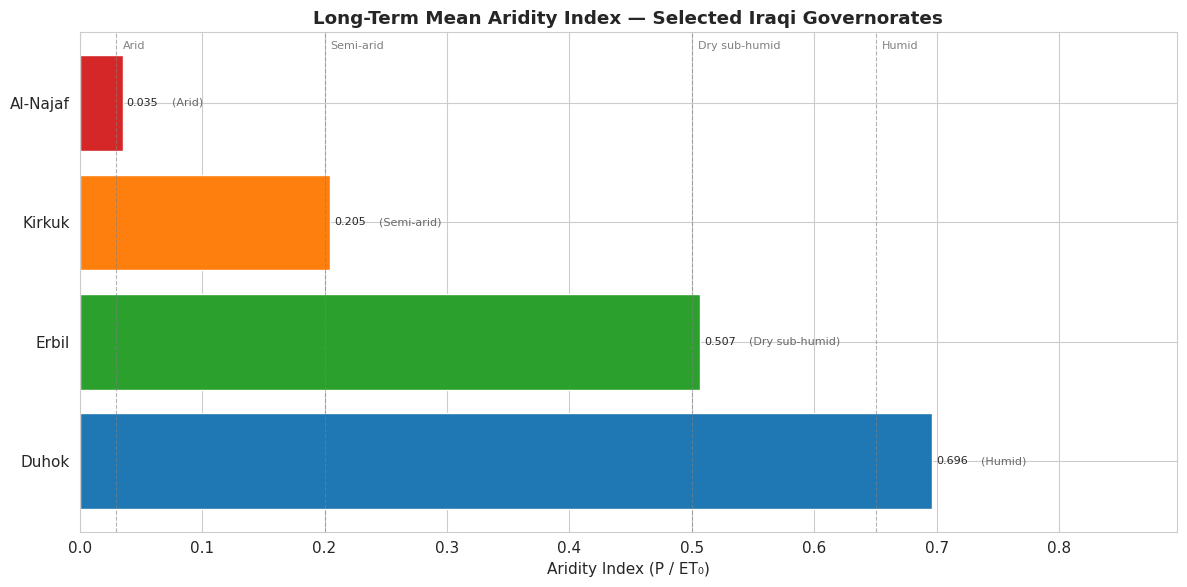

Aridity classification by selected governorate:
--------------------------------------------------
  Humid           : Duhok
  Dry sub-humid   : Erbil
  Semi-arid       : Kirkuk
  Arid            : Al-Najaf


In [ ]:
# =============================================================================
# ARIDITY INDEX (P / ET₀) — BAR CHART WITH CLASSIFICATION THRESHOLDS
# =============================================================================

# ai_mean already loaded in cell 9 — one column of long-term mean AI per governorate
ai_series = ai_mean.iloc[:, 0]

# UNEP aridity classification thresholds (Middleton & Thomas 1997)
ARIDITY_CLASSES = [
    (0.65, 'Humid',         '#1f77b4'),
    (0.50, 'Dry sub-humid', '#2ca02c'),
    (0.20, 'Semi-arid',     '#ff7f0e'),
    (0.03, 'Arid',          '#d62728'),
    (0.00, 'Hyper-arid',    '#8B0000'),
]

def aridity_class(ai):
    for threshold, label, _ in ARIDITY_CLASSES:
        if ai >= threshold:
            return label
    return 'Hyper-arid'

def aridity_color(ai):
    for threshold, _, color in ARIDITY_CLASSES:
        if ai >= threshold:
            return color
    return '#8B0000'

# Define the specific governorates and their desired order
selected_govs_order = ['Duhok', 'Erbil', 'Kirkuk', 'Al-Najaf']

# Filter ai_series and reindex to enforce the specific display order
ai_series_filtered = ai_series.reindex(selected_govs_order)

# Recalculate bar_colors for the filtered series
bar_colors_filtered = [aridity_color(v) for v in ai_series_filtered.values]

fig, ax = plt.subplots(figsize=(12, max(6, len(selected_govs_order) * 0.8))) # Adjust figure size
bars = ax.barh(ai_series_filtered.index, ai_series_filtered.values, color=bar_colors_filtered, edgecolor='white')

# Classification threshold lines
thresholds = [(0.65, 'Humid'), (0.50, 'Dry sub-humid'), (0.20, 'Semi-arid'), (0.03, 'Arid')]
for t, lbl in thresholds:
    ax.axvline(x=t, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.text(t + 0.005, ax.get_ylim()[1] * 0.98, lbl,
            fontsize=8, color='gray', va='top')

ax.set_xlabel('Aridity Index (P / ET₀)')
ax.set_title('Long-Term Mean Aridity Index — Selected Iraqi Governorates', fontweight='bold')

# Value labels and Aridity Class labels for each bar
for bar, val, gov_name in zip(bars, ai_series_filtered.values, ai_series_filtered.index):
    # Numerical value label
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)
    # Aridity class label
    class_label = aridity_class(val)
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2,
            f'({class_label})', va='center', fontsize=8, color='dimgray')

# Adjust x-axis limits to accommodate the new text labels if they get cut off
ax.set_xlim(right=ai_series_filtered.max() + 0.20) # Increased padding for labels

plt.tight_layout()
plt.show()

print("Aridity classification by selected governorate:")
print("-" * 50)
for gov in selected_govs_order:
    val = ai_series_filtered[gov]
    cls = aridity_class(val)
    print(f"  {cls:16s}: {gov}")

>**🔍 Visualization Lens:** *reflecting on the chart above as it appeared in the analysis*
>
>**What this chart shows:**
The long-term mean aridity index (P/ET₀) for all 18 governorates, sorted highest-to-lowest (least to most arid), with UNEP classification thresholds superimposed.
>
>**What works well:**
Colour-coding bars by aridity class and adding threshold lines makes the classification boundaries legible without a separate legend. Sorting by AI value groups similar climates together, which is more useful than alphabetical order for a chart whose primary purpose is to communicate the severity and extent of aridity.
>
>**What to watch out for:**
The AI is a long-term mean ratio — it describes the average climate, not any individual year. A governorate classified as "arid" (AI = 0.03–0.20) may still experience occasional years where P approaches or briefly exceeds ET₀. Presenting the long-term mean without any indication of inter-annual variability hides the range of conditions that water managers must actually plan for.
>
>**What could be improved:**
Add horizontal error bars showing the inter-quartile range of annual AI across years. This one addition transforms the chart from a static classification into a representation of climate variability — which is often more relevant for planning than the mean alone.
>
>---
>
>🔔 **DISCUSS**
>
>**Duhok (AI = 0.696) is the only governorate that reaches the "humid" class (AI ≥ 0.65); the remaining 17 have AI < 0.65.**
>**A colleague proposes using the Aridity Index alone to decide where to invest in irrigation infrastructure.**
>**What important dimension of the water problem does AI not capture?**
>
>Post your answer in the course forum before reading below.

<details>
<summary style="cursor:pointer; color:#555; font-size:14px; margin-top:10px;"><b>Show answer</b></summary>

<br>

**✅ AI captures average annual balance but not seasonal distribution or inter-annual variability.**

*Two governorates could have the same annual AI but completely different seasonal profiles. A semi-arid governorate (AI ~ 0.20–0.50) where rainfall is concentrated in January–March may support rainfed winter cereals without irrigation, while another with the same AI but rainfall spread across 8 months may be far more suitable. AI also averages out drought years. Planning decisions require both the AI and the seasonal and interannual variability.*

</details>

>💬 **FORUM**
>
>The demo plots long-term mean AI. Compute the AI for **each individual year** (divide annual P by annual ET₀, using `rain_annual` and `ret_annual`) and plot a line chart showing AI over time for the three representative governorates.
>
>In how many years did any governorate cross from one aridity class into another? What year was the worst for aridity across the country?
>
>Post your time-series figure and a brief answer.

## 💾 7. Downloading the plots

For any single chart elsewhere in this notebook, right-click on the image and choose
*Save image as…* — no code needed.

For the **small-multiples panels** (which render as one large figure), use the cell below.
Three options are available:

- **All 18 panels in one file** — one PDF or PNG with the full grid.
- **One governorate at a time** — a separate file per governorate or choose one specific governorate.
- **Groups of N** — e.g. 3 per file, useful for reports or slides.

All files will be saved in the `output_data/` folder.

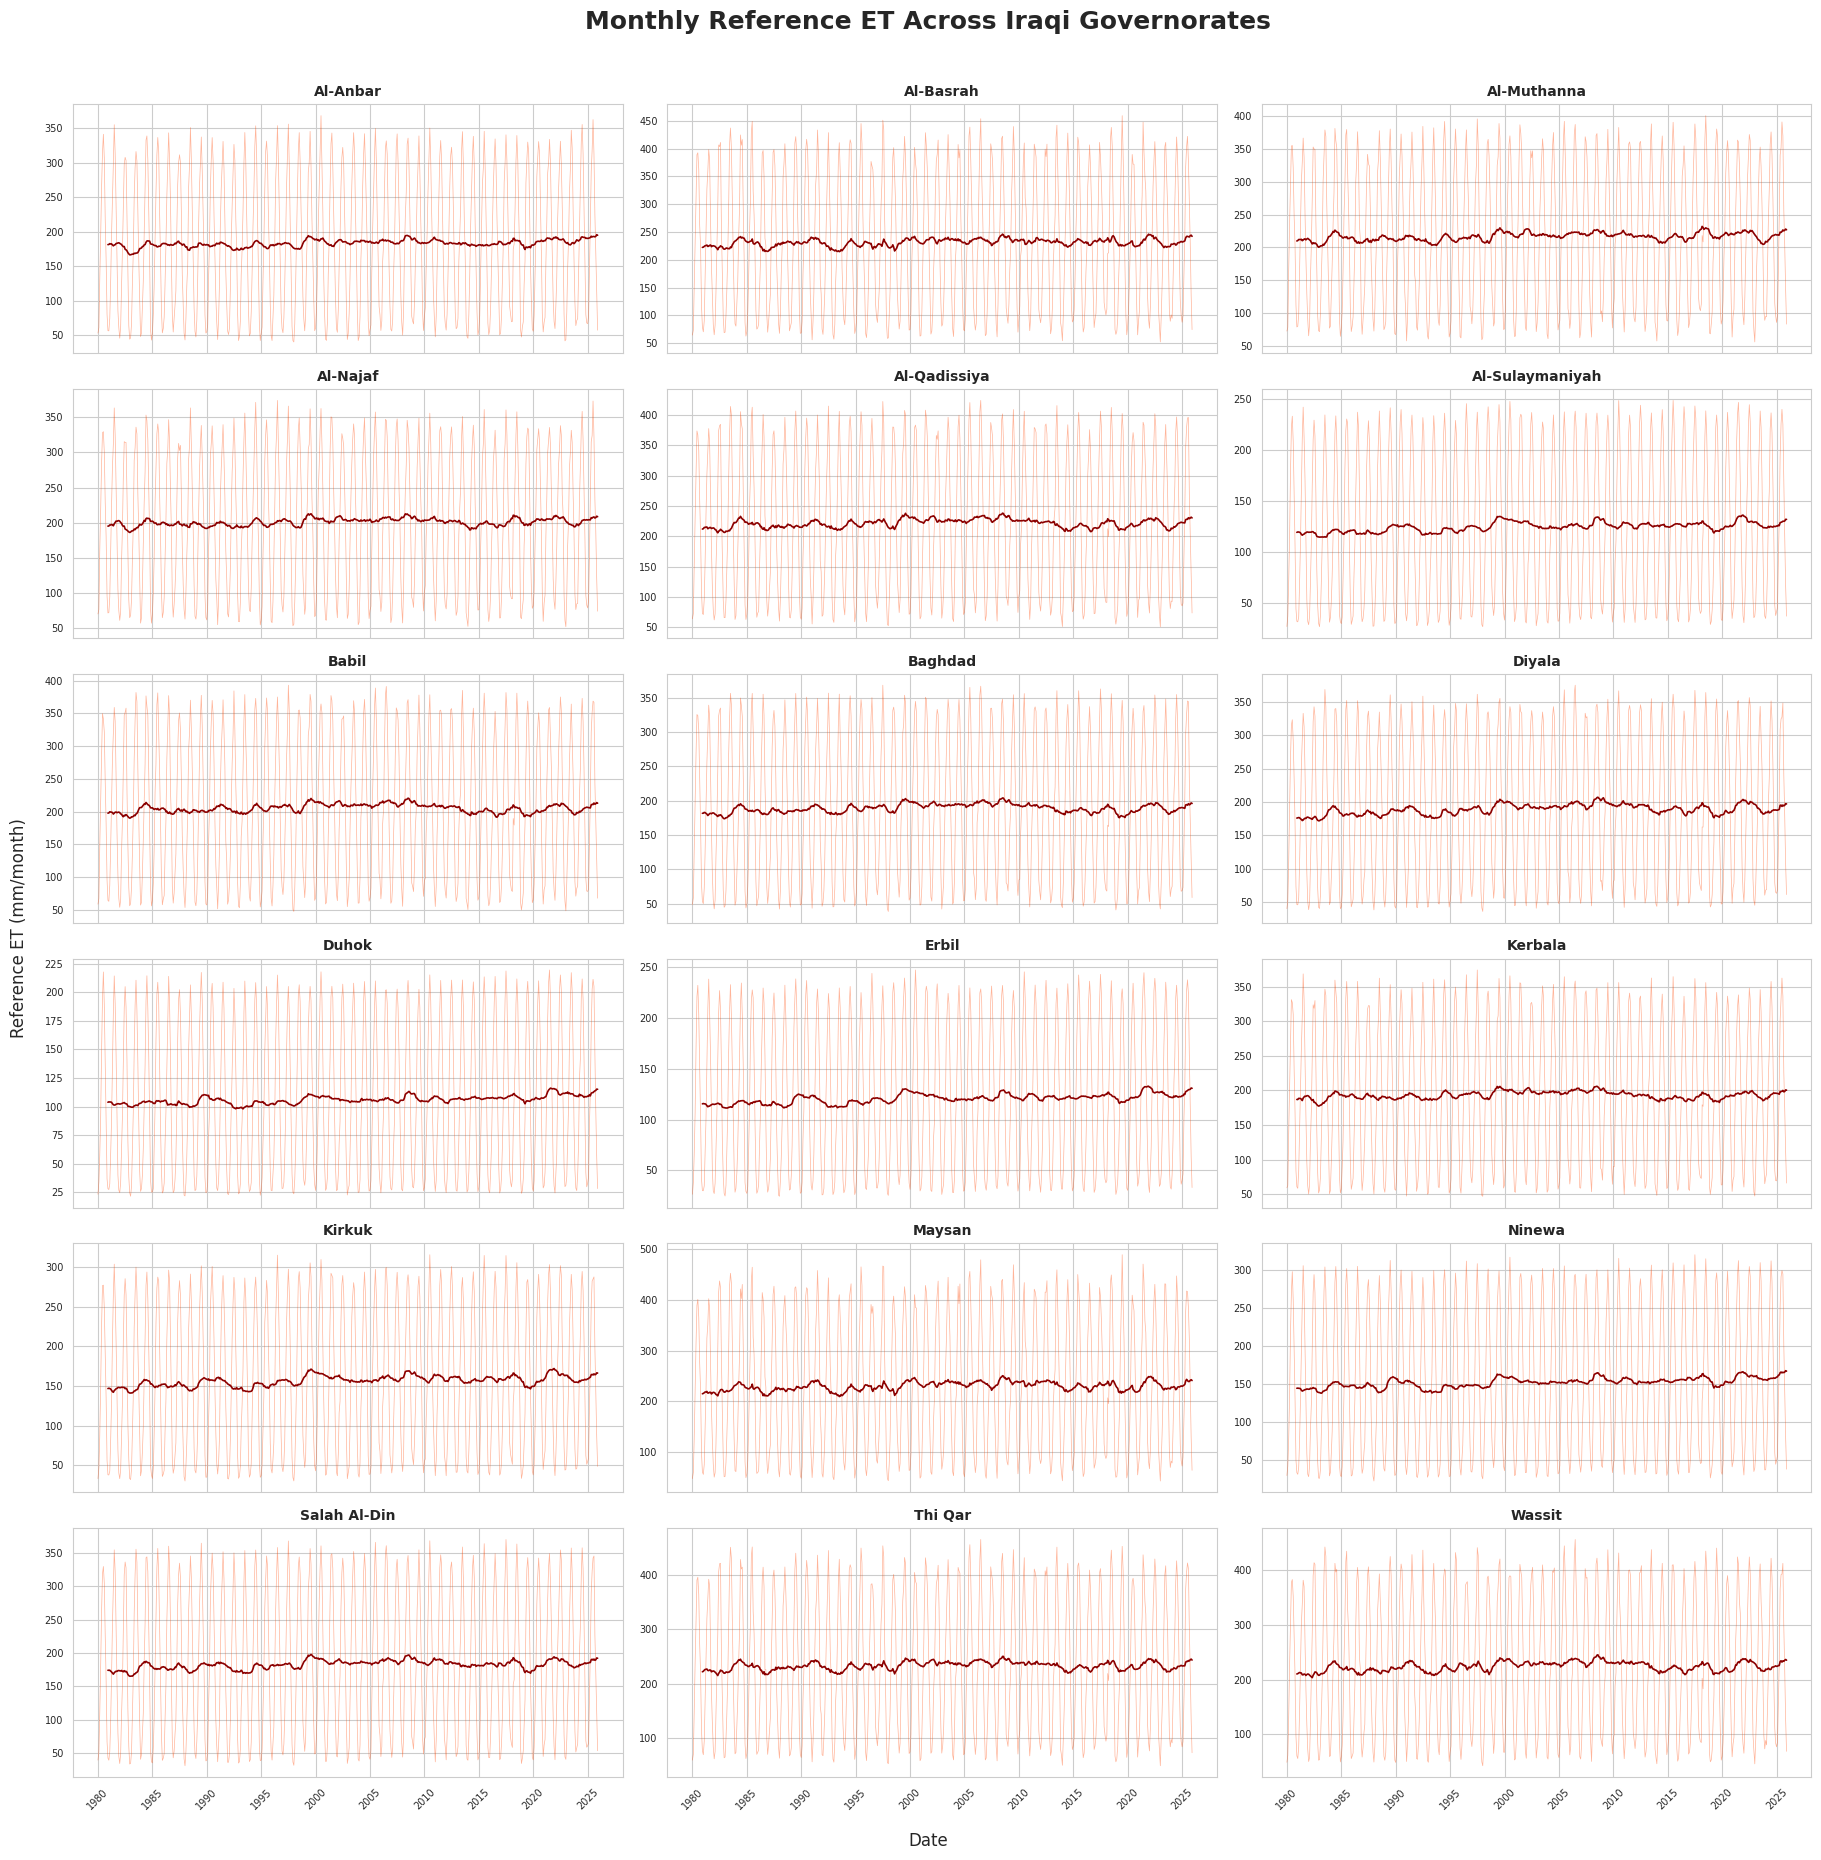

In [ ]:
# =============================================================================
# SAVE / DOWNLOAD — REFERENCE ET SMALL MULTIPLES
# =============================================================================
# Rebuild the figure first (plt.show() above closes it; we need it open to save).

n_cols = 3
n_rows = (n_gov + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
fig.suptitle('Monthly Reference ET Across Iraqi Governorates',
             fontsize=18, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for idx, gov in enumerate(governorates):
    ax = axes_flat[idx]
    ax.plot(df_ret[gov], color='orangered', alpha=0.4, linewidth=0.5)
    ax.plot(df_ret[gov].rolling(12).mean(), color='darkred', linewidth=1.2)
    ax.set_title(gov, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
for idx in range(n_gov, len(axes_flat)):
    axes_flat[idx].set_visible(False)
fig.text(0.5, -0.01, 'Date', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Reference ET (mm/month)', va='center', rotation='vertical', fontsize=12)
plt.tight_layout()

plt.show()

In [ ]:
# =============================================================================
# OPTION 1 — Save all 18 panels as ONE file
# =============================================================================
#  Change the extension to .pdf if you prefer a vector file.
fig.savefig(os.path.join(output_folder, 'ET_all_governorates.png'), dpi=150, bbox_inches='tight')
print("✅ Saved: ET_all_governorates.png")


In [ ]:
# =============================================================================
# OPTION 2 — Save ONE file per governorate
# =============================================================================
# Each governorate gets its own figure and its own file.
# To save only one specific governorate, uncomment the line below and set the name:
# governorates = ['Duhok']

for gov in governorates:
     fig_single, ax_single = plt.subplots(figsize=(6, 3))
     ax_single.plot(df_ret[gov], color='orangered', alpha=0.4, linewidth=0.5)
     ax_single.plot(df_ret[gov].rolling(12).mean(), color='darkred', linewidth=1.2)
     ax_single.set_title(gov, fontsize=11, fontweight='bold')
     ax_single.set_ylabel('Reference ET (mm/month)')
     ax_single.tick_params(axis='x', rotation=45, labelsize=8)
     plt.tight_layout()
     fig_single.savefig(os.path.join(output_folder, f'ET_{gov}.png'), dpi=150, bbox_inches='tight')
     plt.close(fig_single)
print(f"✅ Saved one file per governorate in '{output_folder}/'")



In [ ]:
# =============================================================================
# OPTION 3 — Save in groups of N (e.g. 3 per file — useful for slides or reports)
# =============================================================================
# Change group_size to however many panels you want per file.

group_size = 3
for i in range(0, n_gov, group_size):
    group = governorates[i : i + group_size]
    fig_g, axes_g = plt.subplots(1, len(group), figsize=(6 * len(group), 4), sharex=True)
    if len(group) == 1:
        axes_g = [axes_g]
    for ax_g, gov in zip(axes_g, group):
        ax_g.plot(df_ret[gov], color='orangered', alpha=0.4, linewidth=0.5)
        ax_g.plot(df_ret[gov].rolling(12).mean(), color='darkred', linewidth=1.2)
        ax_g.set_title(gov, fontsize=10, fontweight='bold')
        ax_g.tick_params(axis='x', rotation=45, labelsize=7)
    plt.tight_layout()
    filename = f"ET_group_{i // group_size + 1}.png"
    fig_g.savefig(os.path.join(output_folder, filename), dpi=150, bbox_inches='tight')
    plt.close(fig_g)
    print(f"✅ Saved: {filename}")

✅ Saved: ET_group_1.png
✅ Saved: ET_group_2.png
✅ Saved: ET_group_3.png
✅ Saved: ET_group_4.png
✅ Saved: ET_group_5.png
✅ Saved: ET_group_6.png
